## Important Python To Load and Inspect Data

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_excel('dataset/premiums.xlsx')
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [3]:
# making the columns uniform
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339


# Exploratory Data Analysis (EDA)

In [4]:
# checking the number of rows and columns
df.shape

(50000, 13)

In [5]:
# data type of datasets and columns
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    50000 non-null  int64 
 1   gender                 50000 non-null  object
 2   region                 50000 non-null  object
 3   marital_status         50000 non-null  object
 4   number_of_dependants   50000 non-null  int64 
 5   bmi_category           50000 non-null  object
 6   smoking_status         49989 non-null  object
 7   employment_status      49998 non-null  object
 8   income_level           49987 non-null  object
 9   income_lakhs           50000 non-null  int64 
 10  medical_history        50000 non-null  object
 11  insurance_plan         50000 non-null  object
 12  annual_premium_amount  50000 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 5.0+ MB
None


In [6]:
#  there are certain null and mising values
df.isnull().sum()


age                       0
gender                    0
region                    0
marital_status            0
number_of_dependants      0
bmi_category              0
smoking_status           11
employment_status         2
income_level             13
income_lakhs              0
medical_history           0
insurance_plan            0
annual_premium_amount     0
dtype: int64

In [7]:
df[df['smoking_status'].isna()]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
177,26,Female,Southwest,Married,3,Underweight,NaN,Salaried,> 40L,69,Diabetes,Gold,22605
15648,47,Male,Southwest,Married,4,Normal,NaN,Freelancer,25L - 40L,32,Diabetes,Gold,26100
16324,45,Male,Northwest,Married,4,Overweight,NaN,Salaried,10L - 25L,16,High blood pressure & Heart disease,Silver,21881
16941,34,Male,Southwest,Married,5,Normal,NaN,Self-Employed,25L - 40L,35,High blood pressure & Heart disease,Gold,25865
16975,23,Male,Southwest,Unmarried,0,Normal,NaN,Freelancer,<10L,3,No Disease,Bronze,6001
18005,61,Female,Southwest,Married,2,Normal,NaN,Self-Employed,25L - 40L,27,Thyroid,Gold,32501
19218,19,Female,Northeast,Unmarried,0,Normal,NaN,Salaried,10L - 25L,23,No Disease,Bronze,9010
20335,50,Female,Northeast,Married,3,Underweight,NaN,Salaried,25L - 40L,25,High blood pressure,Gold,27317
22833,69,Male,Southeast,Married,2,Normal,NaN,Freelancer,<10L,9,Diabetes,Silver,23118
25519,54,Male,Southwest,Married,3,Overweight,NaN,Salaried,> 40L,54,High blood pressure & Heart disease,Silver,24907


In [8]:
df = df.dropna(subset=['smoking_status', 'employment_status', 'income_level'])
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

In [9]:
df.loc[:, df.isna().any()]

""
0
1
2
3
4
...
49995
49996
49997
49998


In [10]:
# Percentage of missing
(df.isna().sum() / len(df)) * 100


age                      0.0
gender                   0.0
region                   0.0
marital_status           0.0
number_of_dependants     0.0
bmi_category             0.0
smoking_status           0.0
employment_status        0.0
income_level             0.0
income_lakhs             0.0
medical_history          0.0
insurance_plan           0.0
annual_premium_amount    0.0
dtype: float64

In [12]:
# check the duplicated records present in the datasets
df.duplicated().sum()

np.int64(0)

In [13]:
# basic statistics of the dataset, help to quick overview  
df.describe()
#  here maximum age is very high
# number of dependents is negative 

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49976.000000,49976.000000,49976.000000,49976.000000
mean,34.591764,1.711842,23.021150,15766.810189
std,15.000378,1.498195,24.221794,8419.995271
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8607.750000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22273.500000
max,356.000000,5.000000,930.000000,43471.000000


In [14]:
# separating text columns in the dataset
text_col=df.select_dtypes(include='object').columns.tolist()

# separating numeric columns in the dataset
num_col=df.select_dtypes(include=['int64', 'float64']).columns.tolist()


In [15]:
text_col

['gender',
 'region',
 'marital_status',
 'bmi_category',
 'smoking_status',
 'employment_status',
 'income_level',
 'medical_history',
 'insurance_plan']

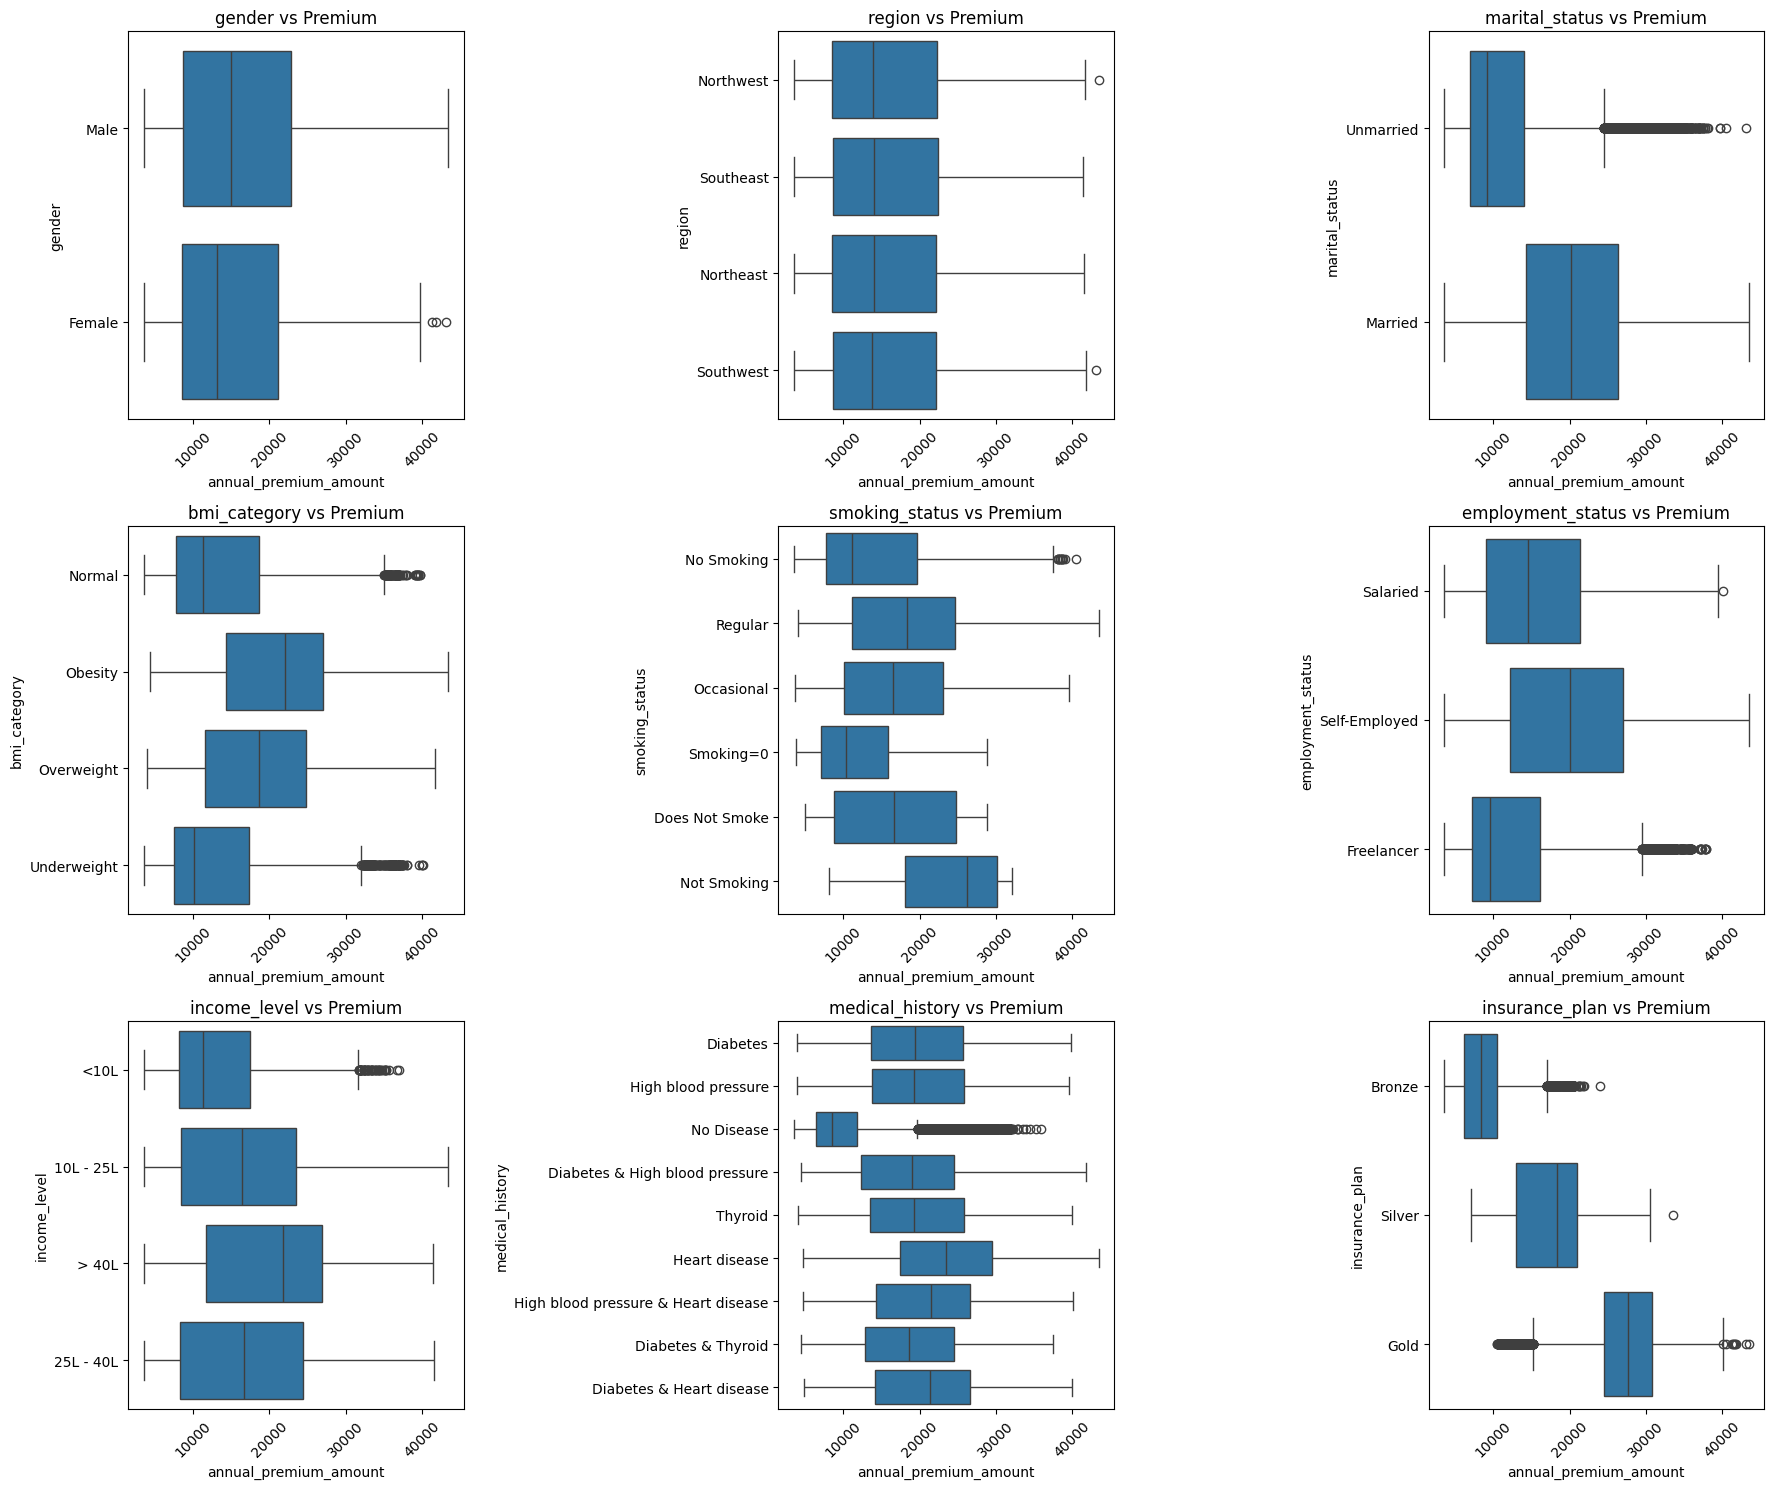

In [16]:
import math
# creating box plot to check the outliers
n_cols = 3   # fixed number of columns per row (standard)
n_rows = math.ceil(len(text_col) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()

# fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, col in zip(axes, text_col):
    sns.boxplot(x='annual_premium_amount', y=col, data=df, ax=ax)
    ax.set_title(f'{col} vs Premium')
    ax.tick_params(axis='x', rotation=45)
    
plt.tight_layout()
plt.show()


In [17]:
num_col

['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount']

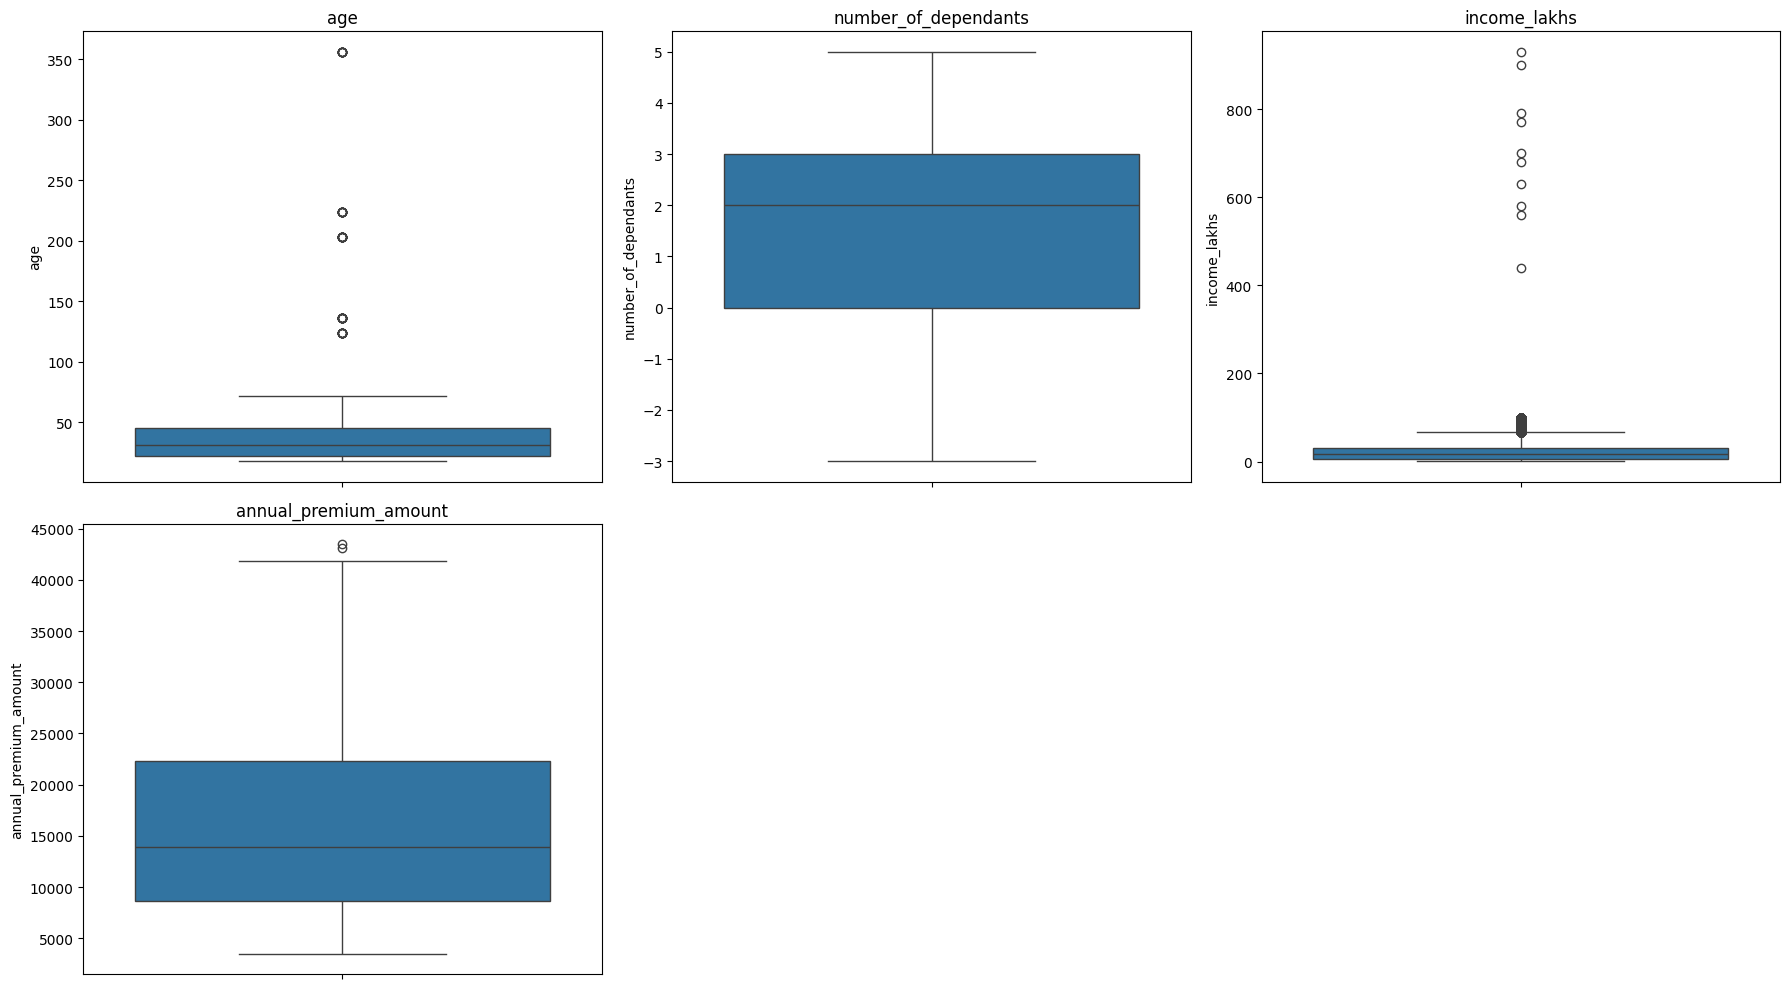

In [18]:
import math
# creating box plot to check the outliers
n_cols = 3   # fixed number of columns per row (standard)
n_rows = math.ceil(len(num_col) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()

# fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, col in zip(axes, num_col):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f'{col}')    
    ax.tick_params(axis='x', rotation=45)

# Remove extra plots
for j in range(len(num_col), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()


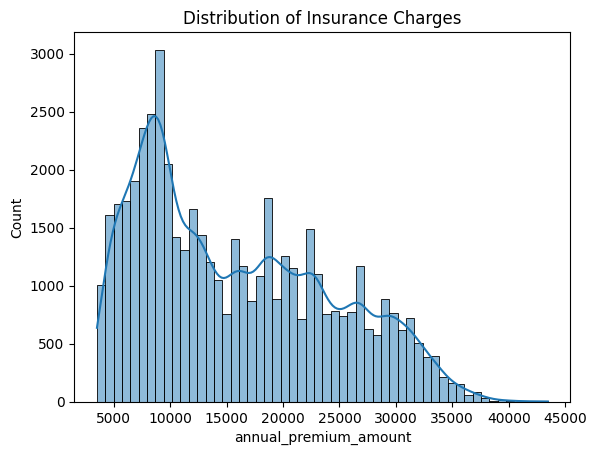

In [19]:
sns.histplot(df['annual_premium_amount'], kde=True)
plt.title('Distribution of Insurance Charges')
plt.show()

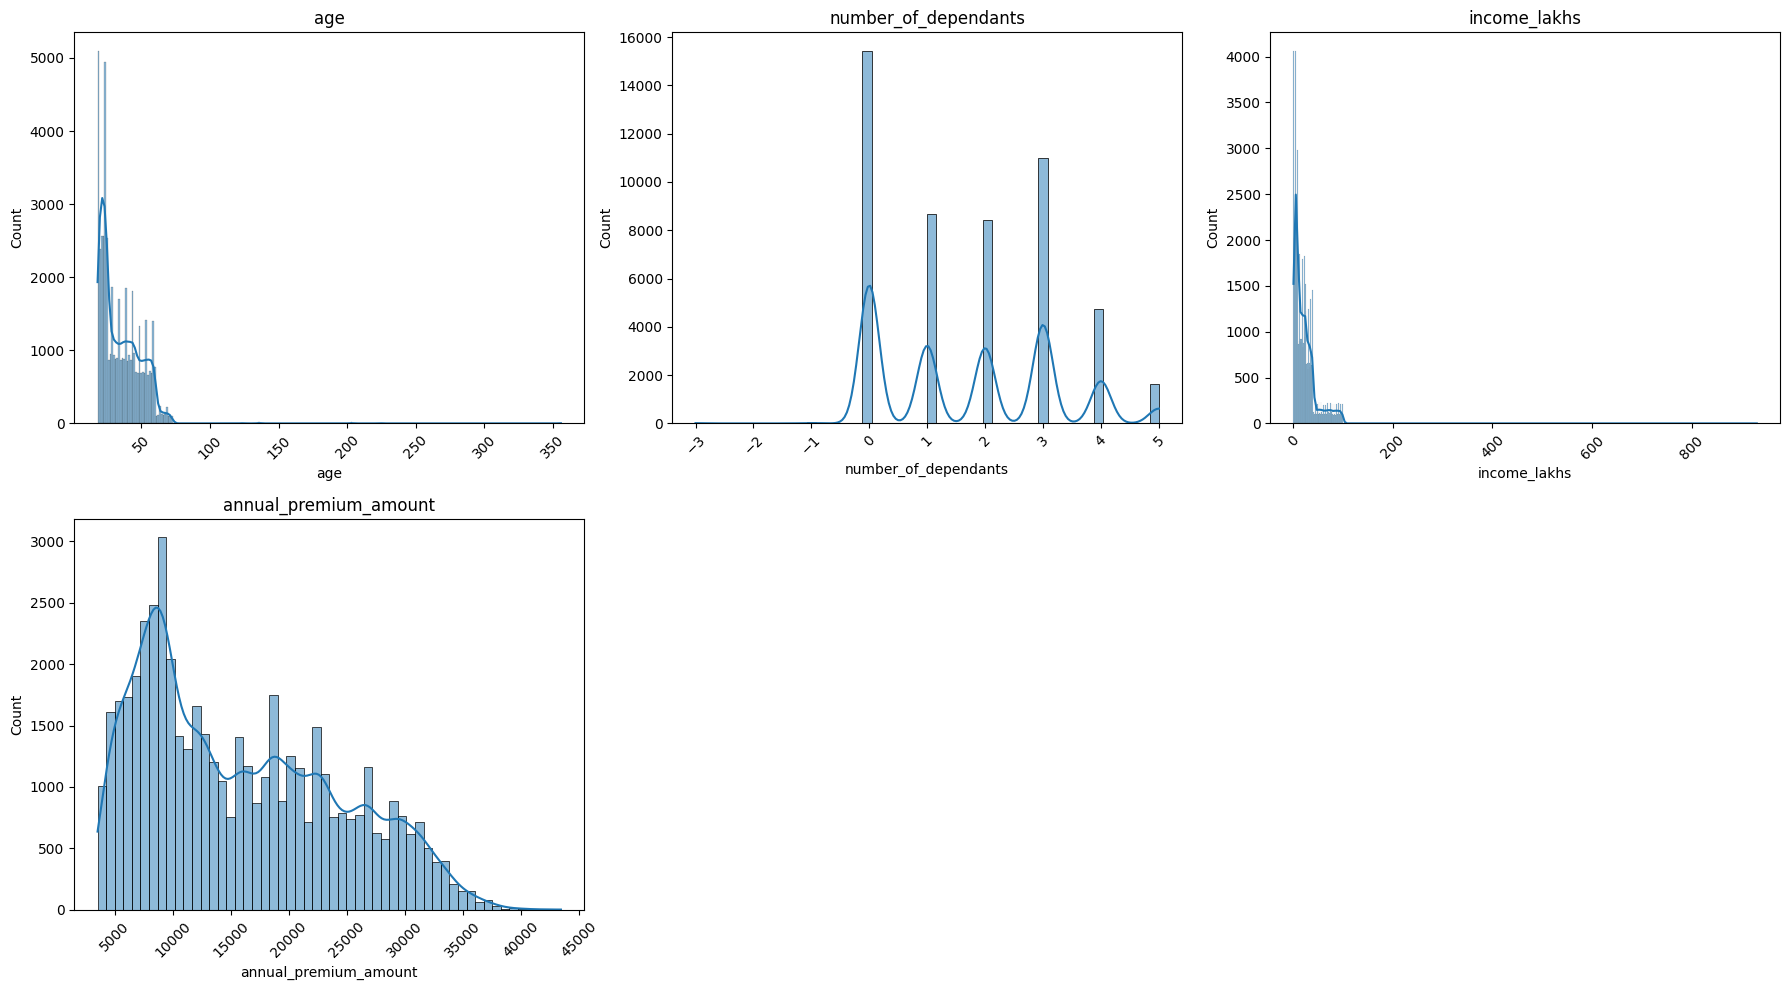

In [20]:
n_cols = 3   # fixed number of columns per row (standard)
n_rows = math.ceil(len(num_col) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()

# fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, col in zip(axes, num_col):
    sns.histplot(df[col], kde=True,ax=ax)    
    ax.set_title(f'{col}')    
    ax.tick_params(axis='x', rotation=45)

# Remove extra plots
for j in range(len(num_col), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()


In [73]:
new_df=df[df['age']<=100]
new_df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49918.000000,49918.000000,49918.000000,49918.000000
mean,34.401839,1.712168,23.025141,15766.589286
std,13.681600,1.498324,24.227912,8419.137327
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22272.000000
max,72.000000,5.000000,930.000000,43471.000000


In [74]:
new_df[new_df['number_of_dependants']<0]['number_of_dependants'].unique()

array([-3, -1])

### Outlier Treatment

- Negative value of number of dependents are meaningless. So, converting it into absolute number.
- Age greater than 100 is rare, so taking it as outlier and removing it.
- Removing salary greater than resonable range

In [75]:
new_df = df[df['age'] <= 100].copy()
new_df['number_of_dependants']=df['number_of_dependants'].abs()
new_df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49918.000000,49918.000000,49918.000000,49918.000000
mean,34.401839,1.717617,23.025141,15766.589286
std,13.681600,1.492074,24.227912,8419.137327
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22272.000000
max,72.000000,5.000000,930.000000,43471.000000


In [78]:
# def get_iqr_bounds():
new_df['income_lakhs'].quantile([0.25,0.75])

0.25     7.0
0.75    31.0
Name: income_lakhs, dtype: float64

In [79]:
def get_iqr_bounds(col):
    Q1,Q3=col.quantile([0.25,0.75])
    IQR=Q3-Q1
    lower_bounds=Q1-1.5*IQR
    upper_bounds=Q3+1.5*IQR
    return lower_bounds,upper_bounds

In [80]:
get_iqr_bounds(new_df['income_lakhs'])

(-29.0, 67.0)

In [81]:
for i in num_col:
    print(f"For column:{i}",get_iqr_bounds(new_df[i]))

For column:age (-12.5, 79.5)
For column:number_of_dependants (-4.5, 7.5)
For column:income_lakhs (-29.0, 67.0)
For column:annual_premium_amount (-11888.0, 42768.0)


In [82]:
print(new_df['number_of_dependants'].value_counts().sort_index())

number_of_dependants
0    15409
1     8701
2     8409
3    11026
4     4722
5     1651
Name: count, dtype: int64


In [83]:
quantile_threshold=new_df.income_lakhs.quantile(0.999)

# df['income_lakhs'].quantile(0.999).sum()
quantile_threshold
new_df=new_df[new_df.income_lakhs<=quantile_threshold]
new_df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49908.000000,49908.000000,49908.000000,49908.000000
mean,34.401579,1.717640,22.889897,15765.739641
std,13.681604,1.492032,22.170699,8418.674061
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22270.500000
max,72.000000,5.000000,100.000000,43471.000000


## Visualisation after removing the outliers

In [84]:
# separating text columns in the dataset
text_col2=new_df.select_dtypes(include='object').columns.tolist()

# separating numeric columns in the dataset
num_col2=new_df.select_dtypes(include=['int64', 'float64']).columns.tolist()


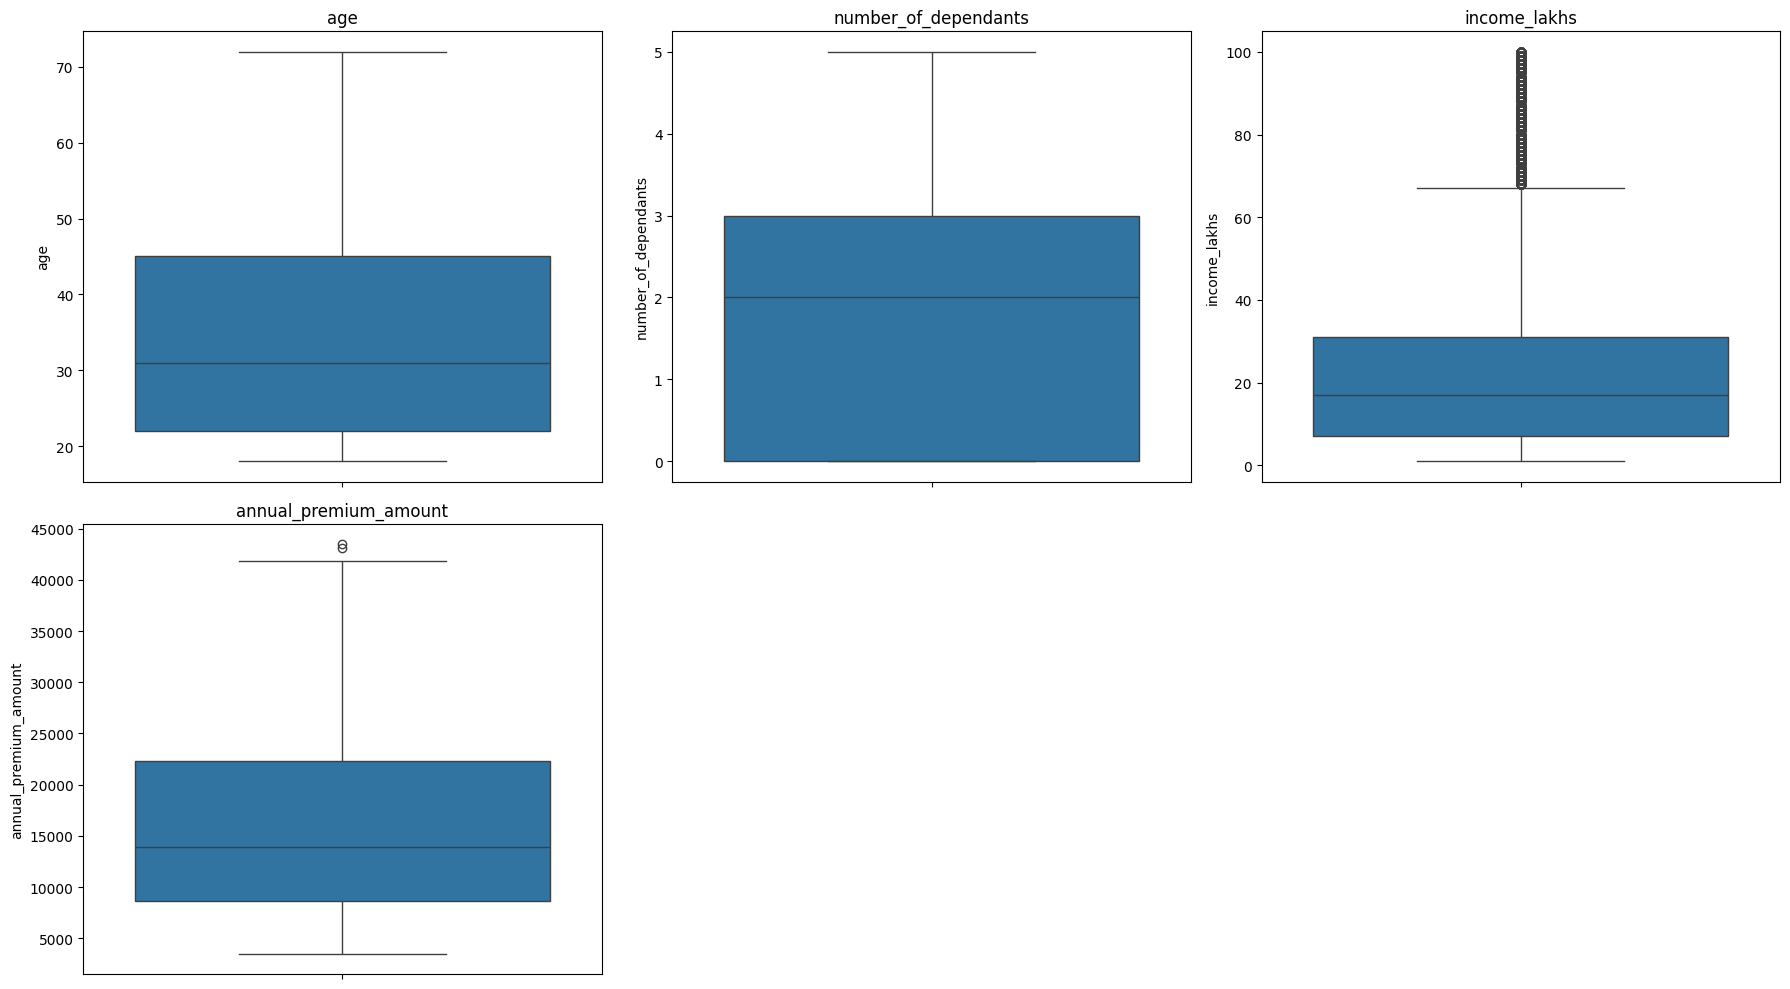

In [85]:
import math
# creating box plot to check the outliers
n_cols = 3   # fixed number of columns per row (standard)
n_rows3 = math.ceil(len(num_col) / n_cols)

fig, axes = plt.subplots(n_rows3, n_cols, figsize=(6*n_cols, 5*n_rows3))
axes = axes.flatten()

# fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, col in zip(axes, num_col):
    sns.boxplot(y=new_df[col], ax=ax)
    ax.set_title(f'{col}')    
    ax.tick_params(axis='x', rotation=45)

# Remove extra plots
for j in range(len(num_col), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()


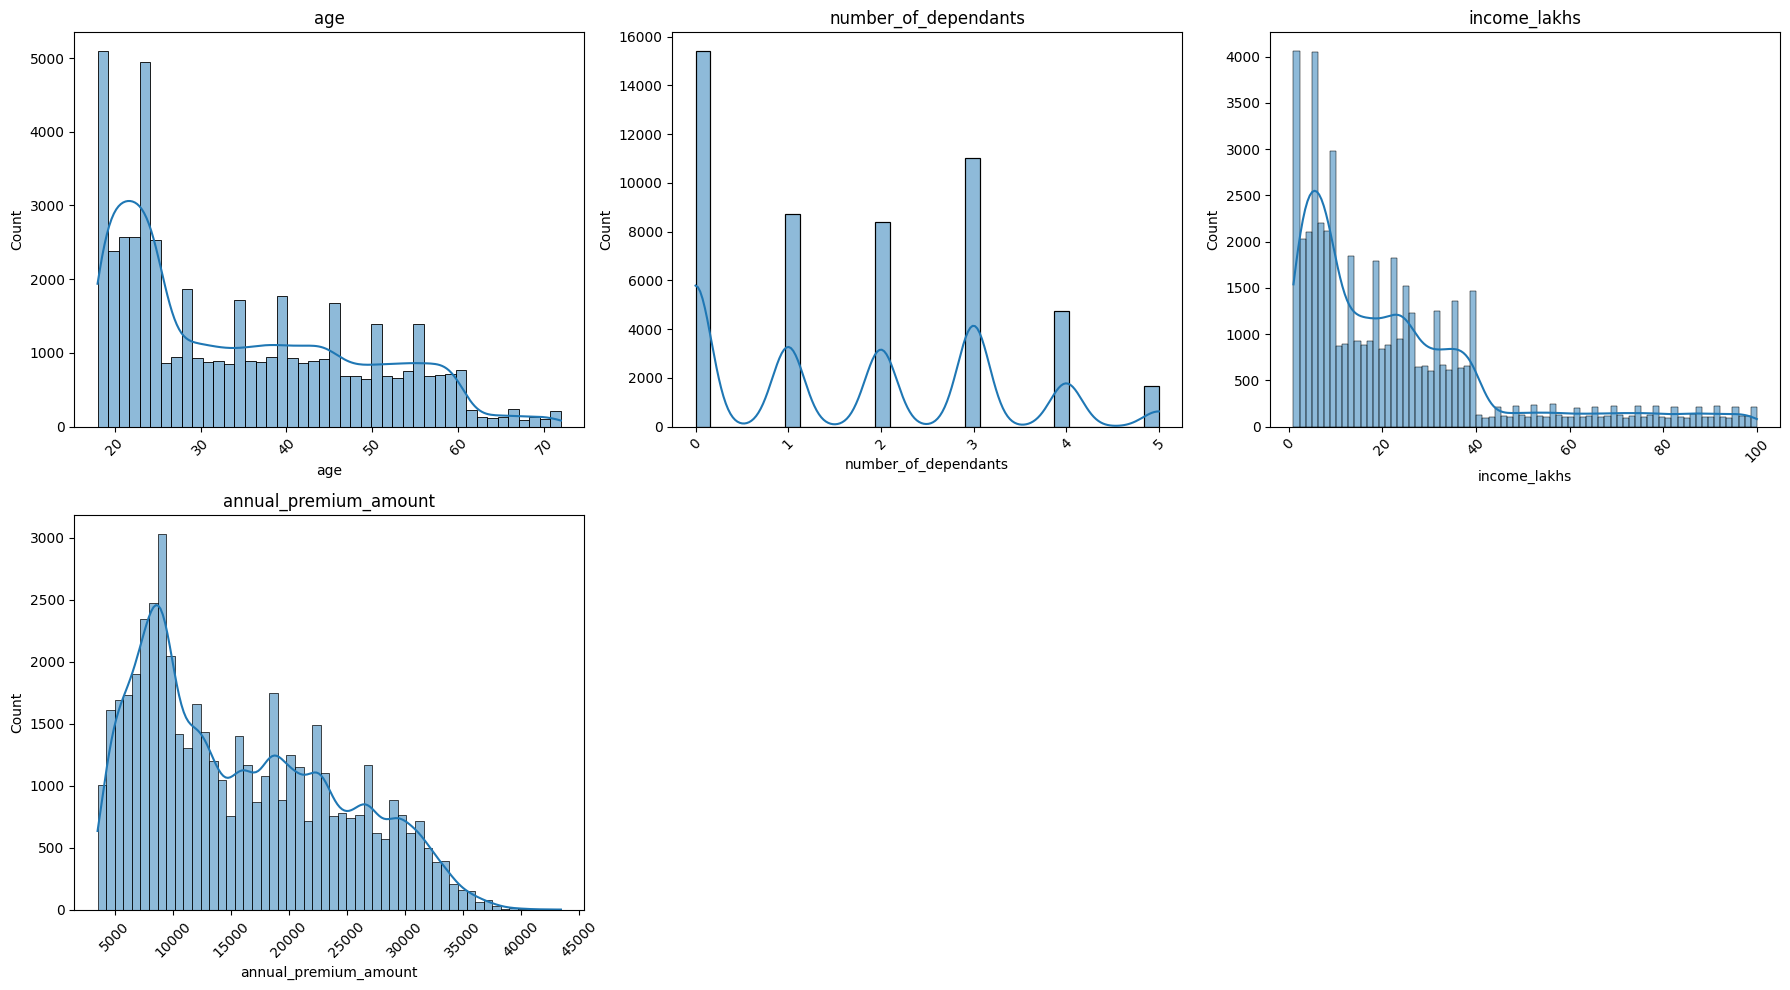

In [86]:
n_cols = 3   # fixed number of columns per row (standard)
n_rows2 = math.ceil(len(num_col2) / n_cols)

fig, axes = plt.subplots(n_rows2, n_cols, figsize=(6*n_cols, 5*n_rows2))
axes = axes.flatten()

# fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, col in zip(axes, num_col):
    sns.histplot(new_df[col], kde=True,ax=ax)    
    ax.set_title(f'{col}')    
    ax.tick_params(axis='x', rotation=45)

# Remove extra plots
for j in range(len(num_col), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()


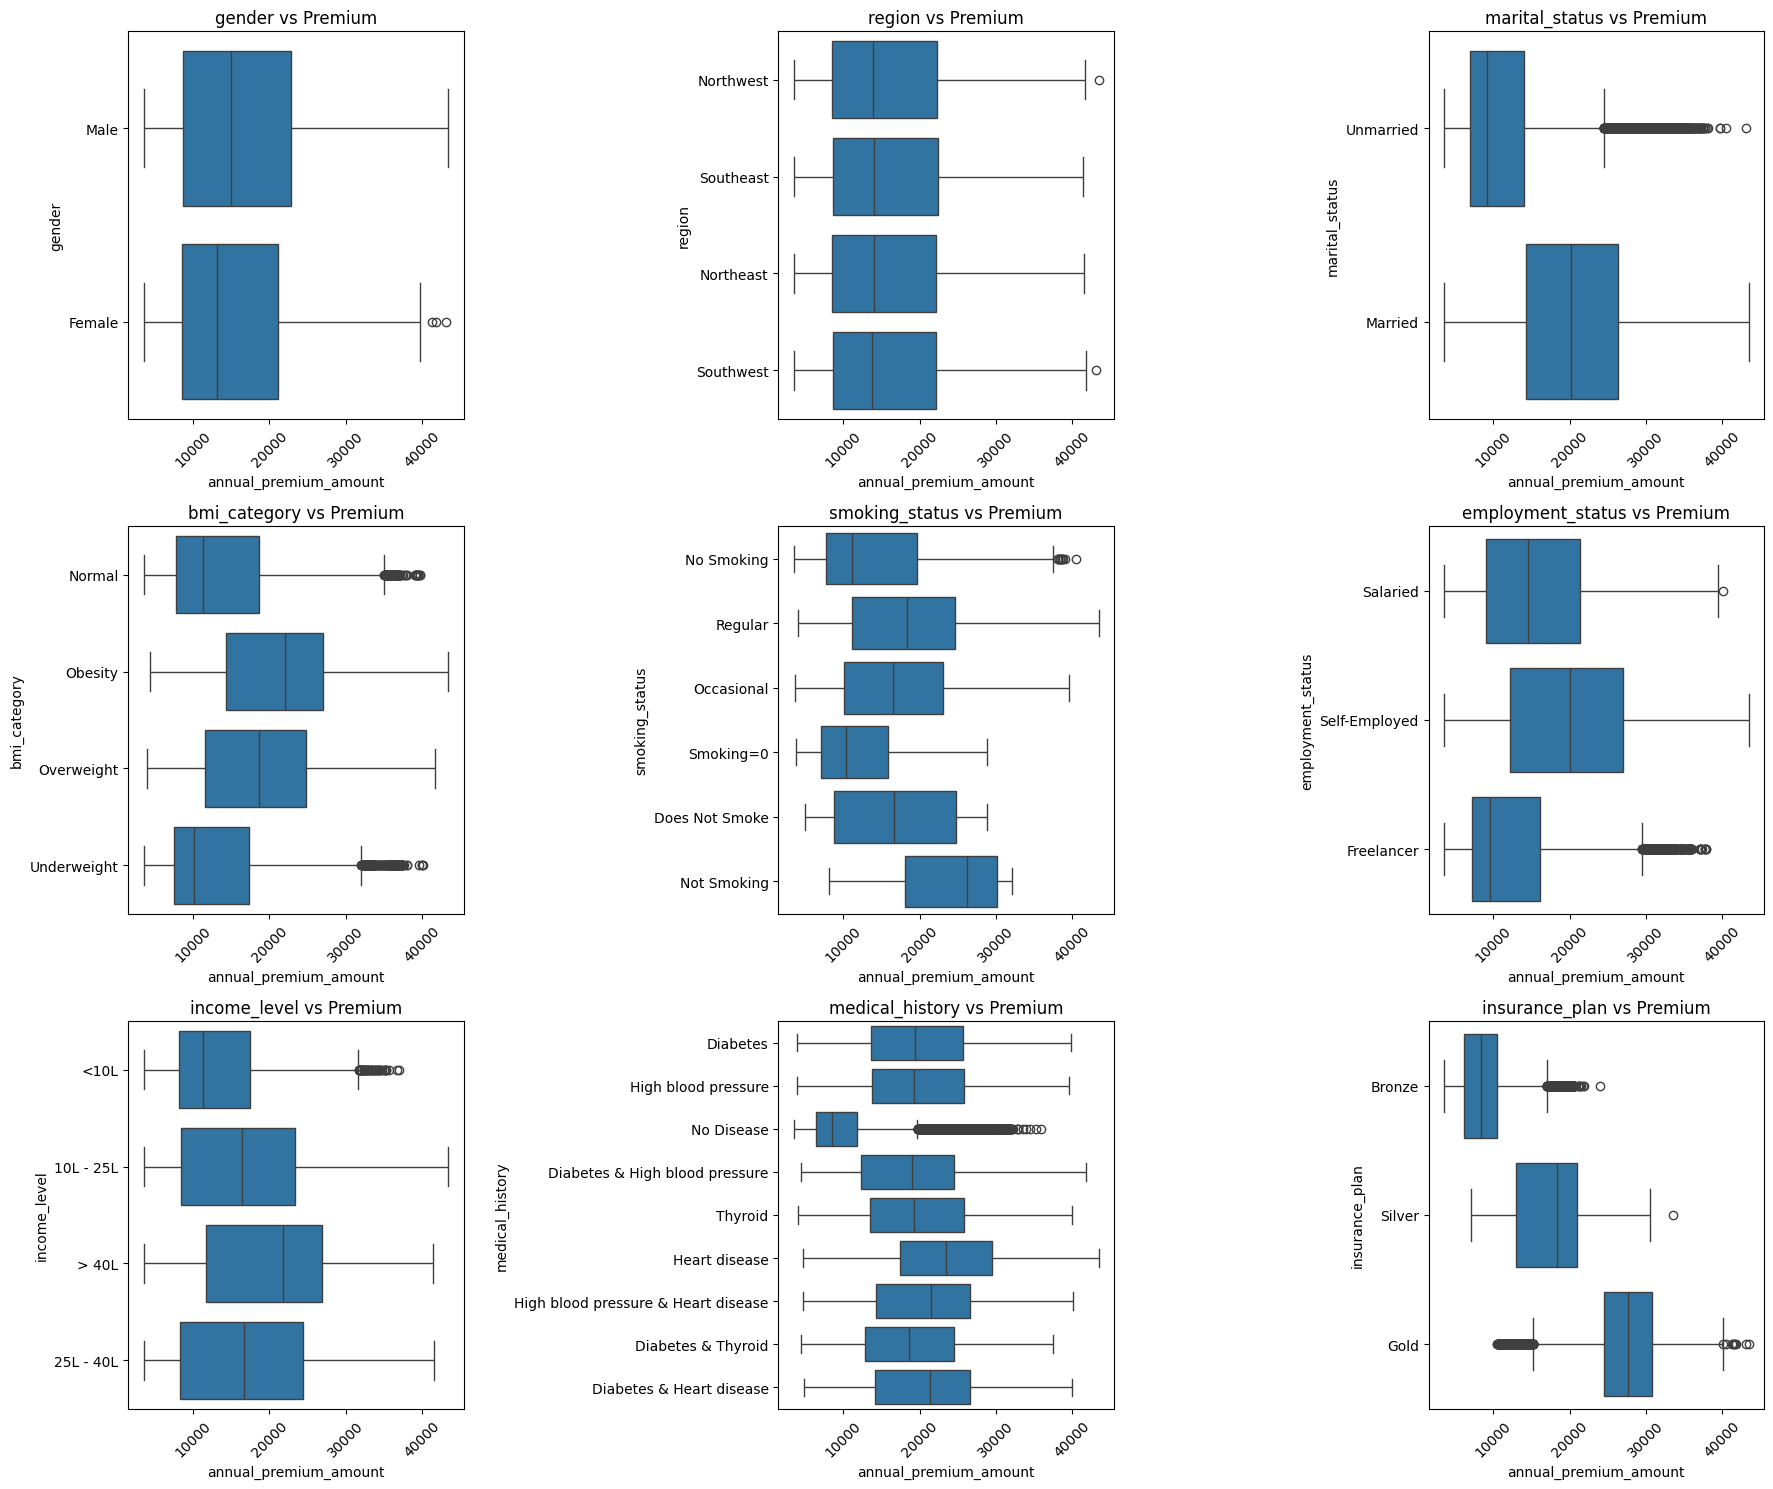

In [87]:
import math
# creating box plot to check the outliers
n_cols = 3   # fixed number of columns per row (standard)
n_rows = math.ceil(len(text_col2) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()

# fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, col in zip(axes, text_col):
    sns.boxplot(x='annual_premium_amount', y=col, data=new_df, ax=ax)
    ax.set_title(f'{col} vs Premium')
    ax.tick_params(axis='x', rotation=45)
    
plt.tight_layout()
plt.show()


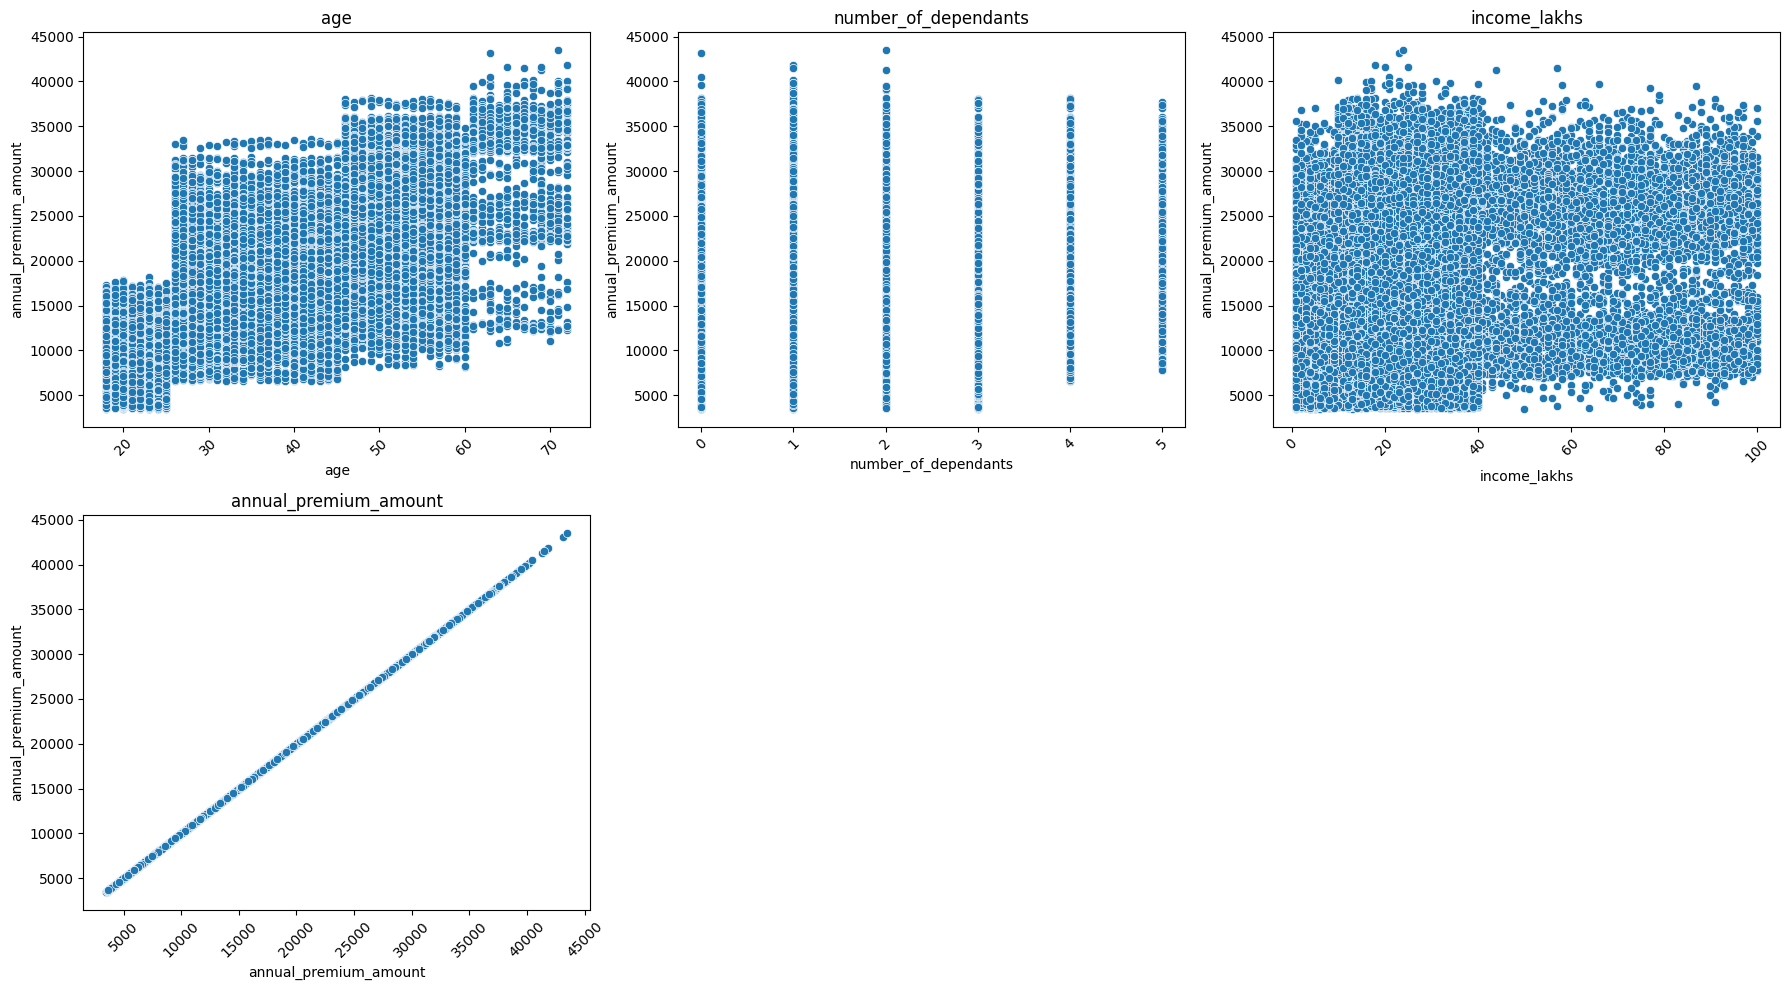

In [88]:
n_cols = 3   # fixed number of columns per row (standard)
n_rows2 = math.ceil(len(num_col2) / n_cols)

fig, axes = plt.subplots(n_rows2, n_cols, figsize=(6*n_cols, 5*n_rows2))
axes = axes.flatten()

for ax, col in zip(axes, num_col):
    sns.scatterplot(x=col,y='annual_premium_amount', data=new_df,ax=ax)    
    ax.set_title(f'{col}')    
    ax.tick_params(axis='x', rotation=45)

# Remove extra plots
for j in range(len(num_col), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()


In [89]:
text_col

['gender',
 'region',
 'marital_status',
 'bmi_category',
 'smoking_status',
 'employment_status',
 'income_level',
 'medical_history',
 'insurance_plan']

In [90]:
for cat_col in text_col:
    print(cat_col,":",new_df[cat_col].unique())

gender : ['Male' 'Female']
region : ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status : ['No Smoking' 'Regular' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
employment_status : ['Salaried' 'Self-Employed' 'Freelancer']
income_level : ['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history : ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan : ['Bronze' 'Silver' 'Gold']


## Smoking Status Correction

- Smoking status category correction and replacing with correct category.

In [91]:
new_df['smoking_status'] = new_df['smoking_status'].replace({
    'Smoking=0': 'No Smoking',
    'Does Not Smoke': 'No Smoking',
    'Not Smoking': 'No Smoking'
})
new_df.smoking_status.unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

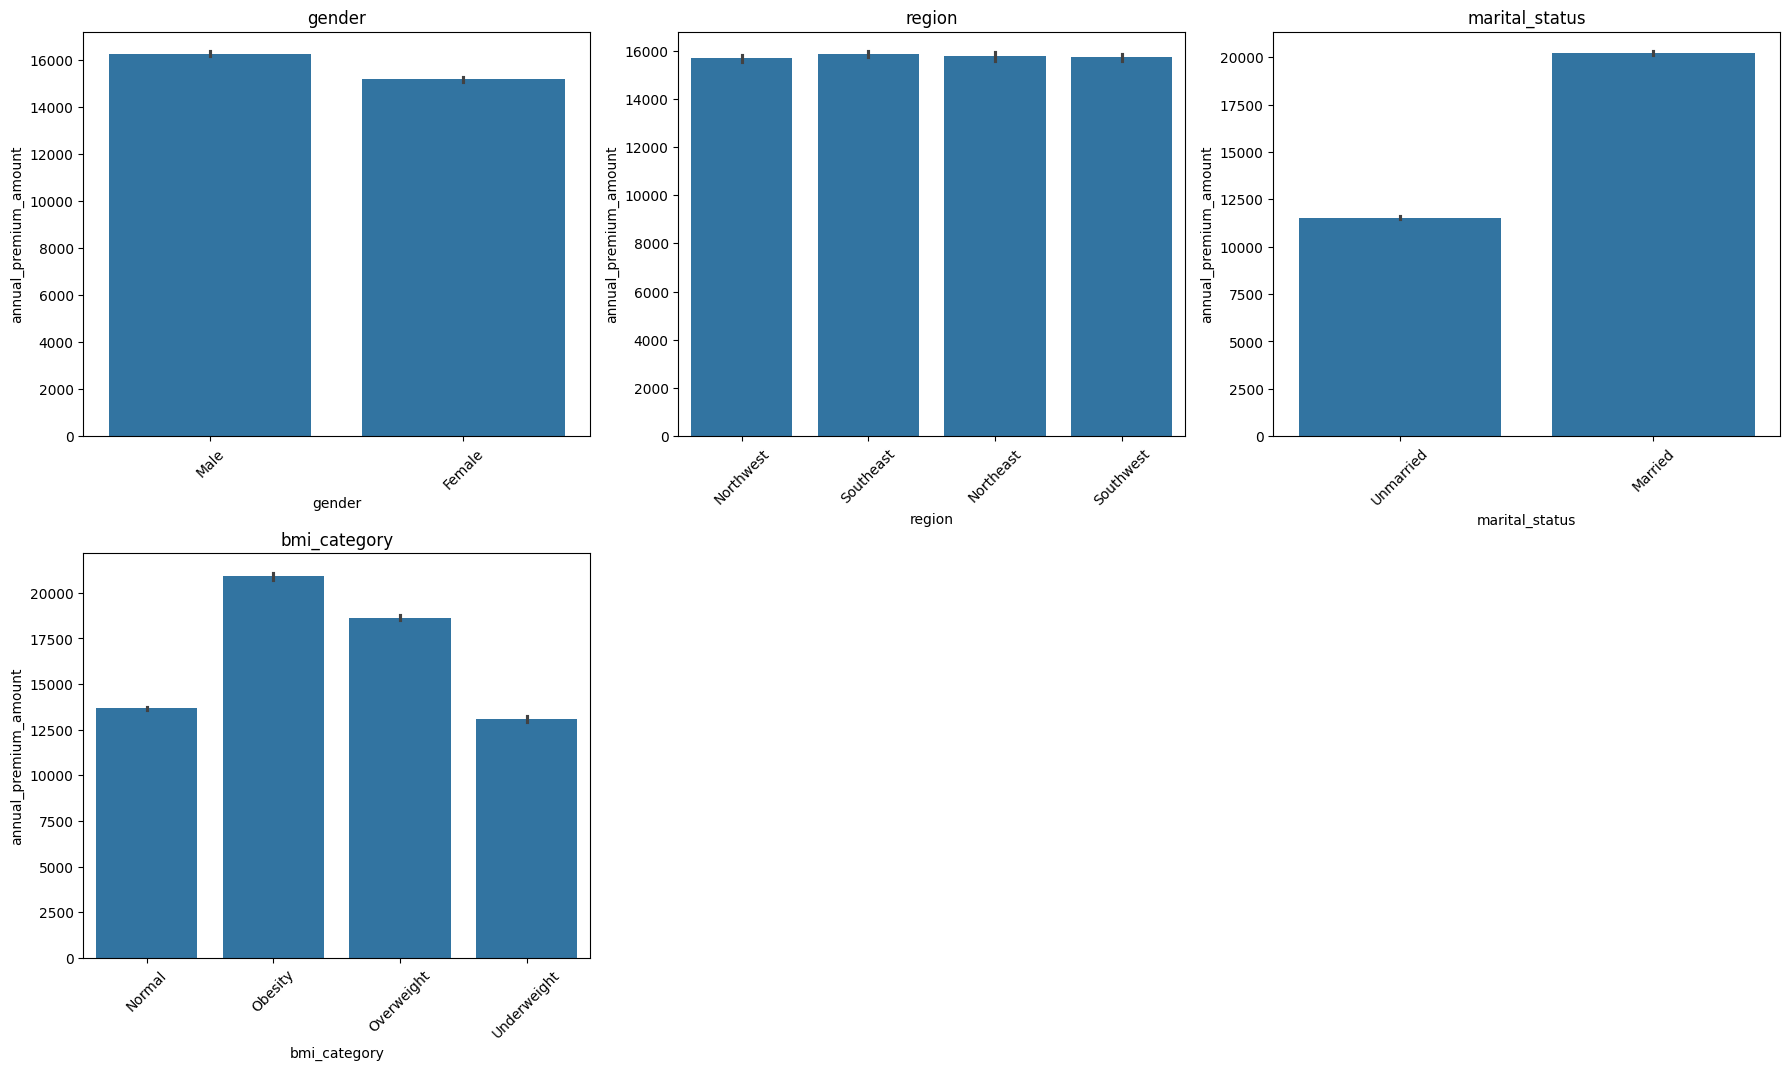

In [92]:
n_cols = 3   # fixed number of columns per row (standard)
n_rows2 = math.ceil(len(text_col2) / n_cols)

fig, axes = plt.subplots(n_rows2, n_cols, figsize=(6*n_cols, 5*n_rows2))
axes = axes.flatten()

for ax, col in zip(axes, text_col2):
    sns.barplot(x=col,y='annual_premium_amount', data=new_df,ax=ax)    
    ax.set_title(f'{col}')    
    ax.tick_params(axis='x', rotation=45)

# Remove extra plots
for j in range(len(num_col), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()


## Bivariate Analysis 

### For Numeric Columns
- Numerical vs Target → Scatterplot + Correlation
- Categorical vs Target → Boxplot / Barplot
- Check linearity & variance differences
- Detect outliers

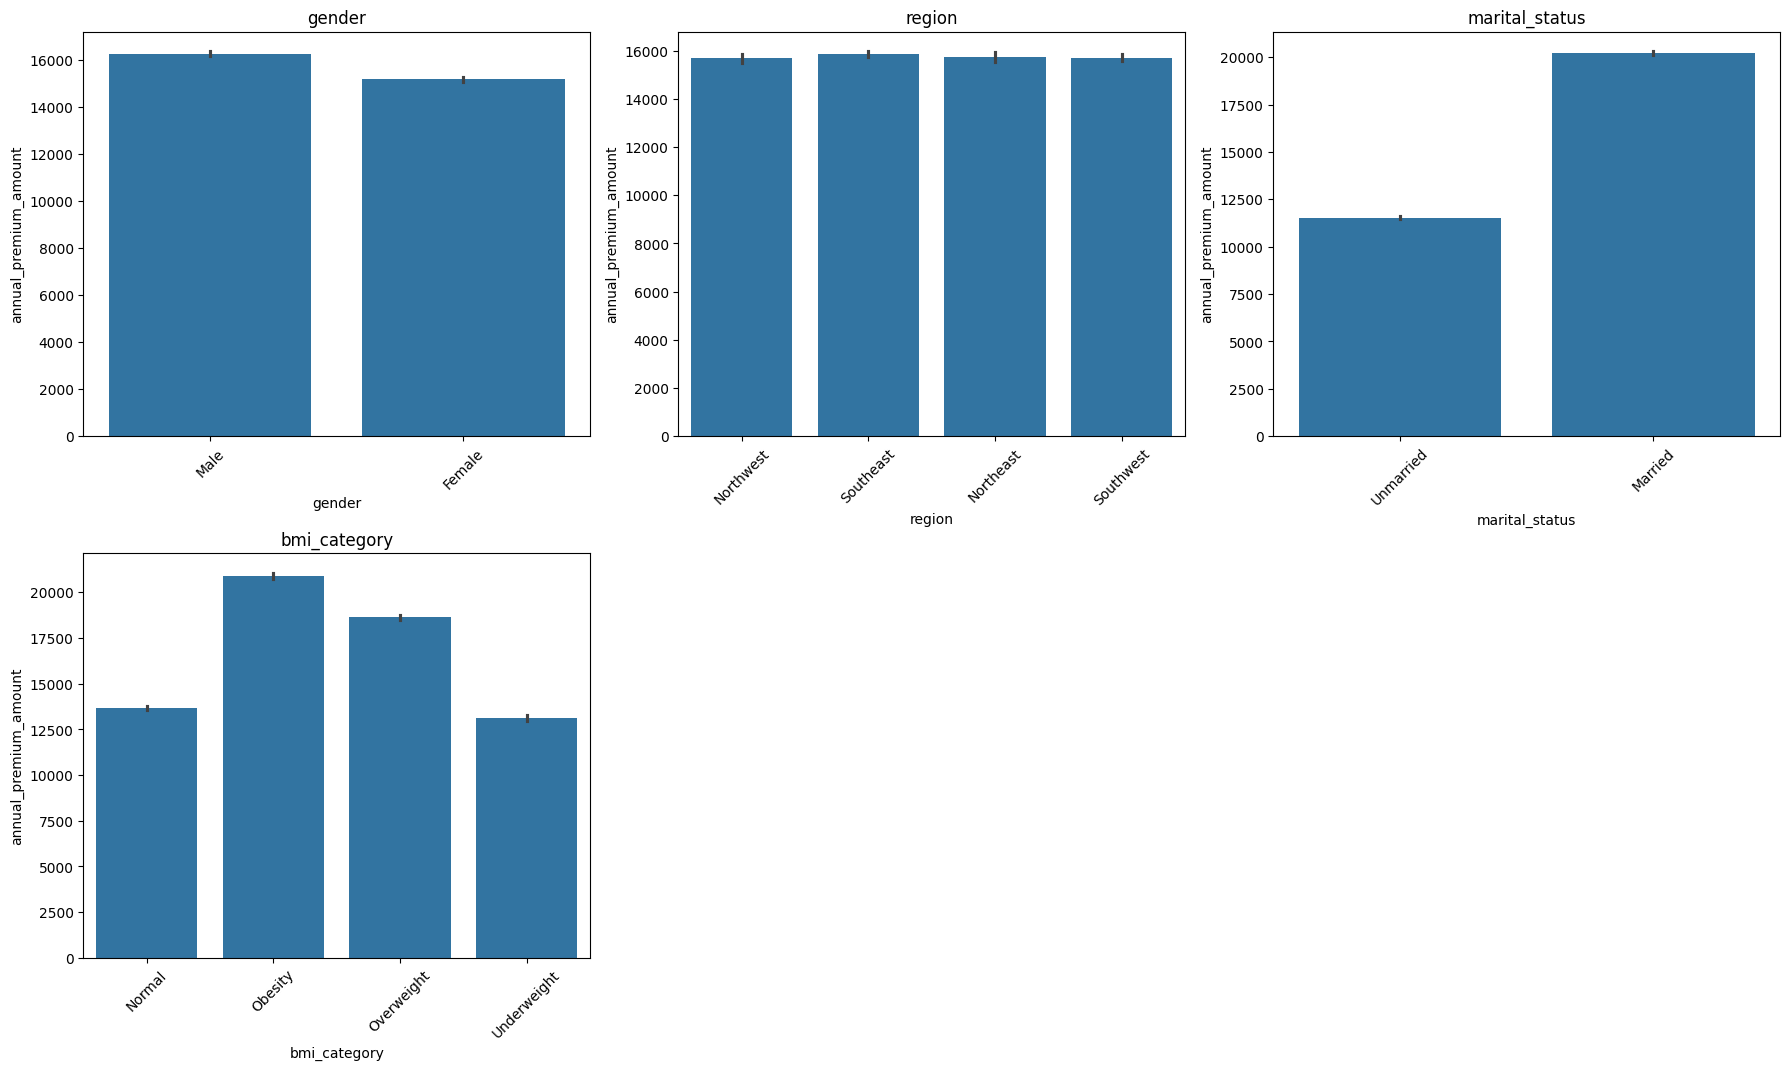

In [93]:
n_cols = 3   # fixed number of columns per row (standard)
n_rows2 = math.ceil(len(text_col2) / n_cols)

fig, axes = plt.subplots(n_rows2, n_cols, figsize=(6*n_cols, 5*n_rows2))
axes = axes.flatten()

for ax, col in zip(axes, text_col2):
    sns.barplot(x=col,y='annual_premium_amount', data=new_df,ax=ax)    
    ax.set_title(f'{col}')    
    ax.tick_params(axis='x', rotation=45)

# Remove extra plots
for j in range(len(num_col), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()


In [94]:

new_df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount'],
      dtype='object')

## Region Vs Medical History

- In all region, diabetes patients frequency are high.
- The second most high patients have blood pressure issue

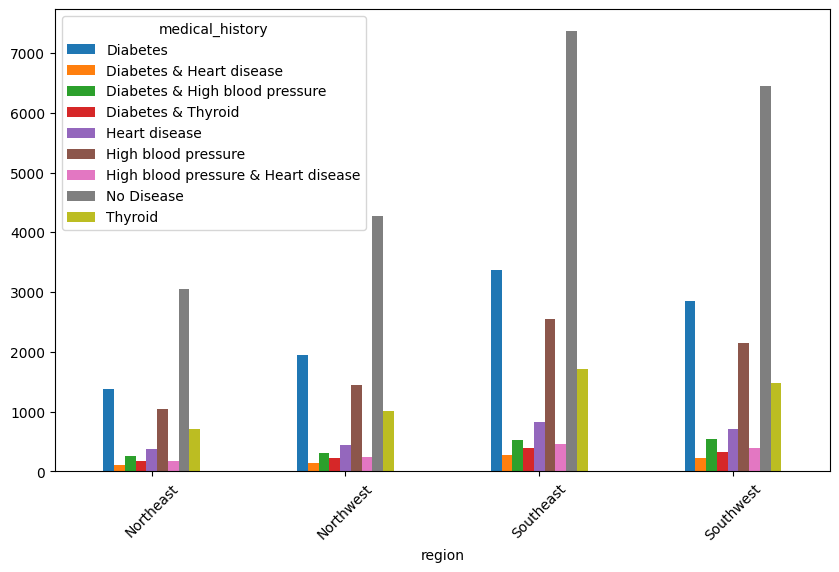

In [95]:
# bins = [0, 20, 40, 60,80,100]
# labels = ['0-20', '20-40', '40-60', '60-80','80-100']
# age_df=new_df
# # new_df['age_group'] = pd.cut(new_df['age'],
#                              bins=bins,
#                              labels=labels,
#                              right=False)

ct = pd.crosstab(new_df['region'],
                 new_df['medical_history'])

ct.plot(kind='bar', figsize=(10,6))
plt.xticks(rotation=45)
plt.show()


## Age group vs income level analysis 

- Among all the age group, less than 10L income frequency is high.
- The 2nd income range is 10L-25L

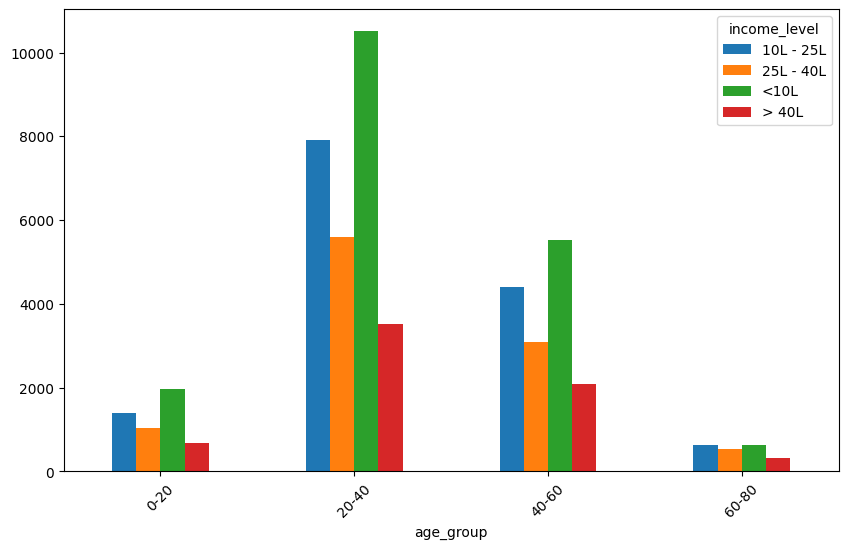

In [96]:
bins = [0, 20, 40, 60,80,100]
labels = ['0-20', '20-40', '40-60', '60-80','80-100']
age_df=new_df
age_df['age_group'] = pd.cut(new_df['age'],
                             bins=bins,
                             labels=labels,
                             right=False)

ct = pd.crosstab(age_df['age_group'],
                 age_df['income_level'])

ct.plot(kind='bar', figsize=(10,6))
plt.xticks(rotation=45)
plt.show()


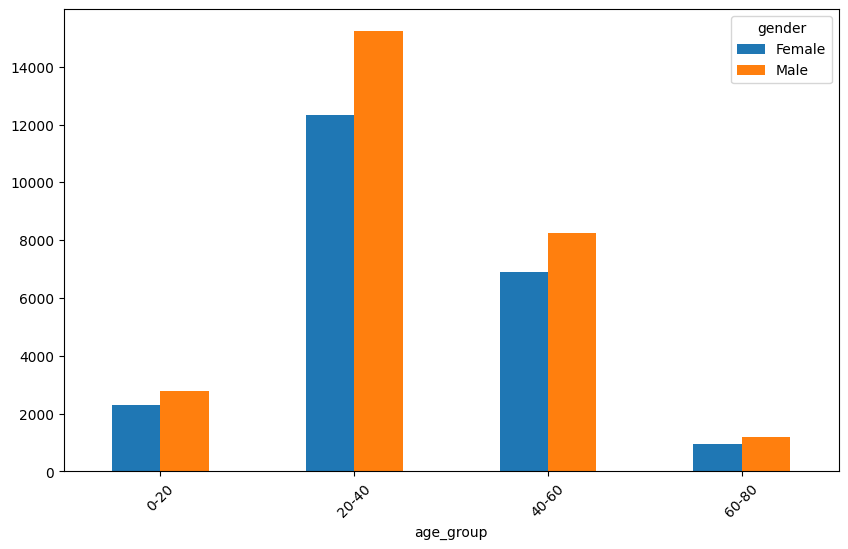

In [97]:
bins = [0, 20, 40, 60,80,100]
labels = ['0-20', '20-40', '40-60', '60-80','80-100']
age_df=new_df
age_df['age_group'] = pd.cut(new_df['age'],
                             bins=bins,
                             labels=labels,
                             right=False)

ct = pd.crosstab(age_df['age_group'],
                 age_df['gender'])

ct.plot(kind='bar', figsize=(10,6))
plt.xticks(rotation=45)
plt.show()


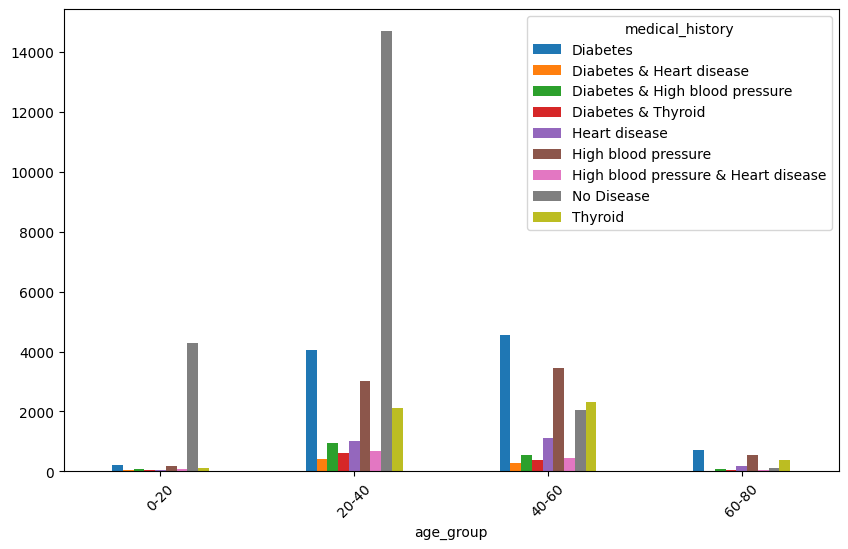

In [98]:
bins = [0, 20, 40, 60,80,100]
labels = ['0-20', '20-40', '40-60', '60-80','80-100']

new_df['age_group'] = pd.cut(new_df['age'],
                             bins=bins,
                             labels=labels,
                             right=False)

ct = pd.crosstab(new_df['age_group'],
                 new_df['medical_history'])

ct.plot(kind='bar', figsize=(10,6))
plt.xticks(rotation=45)
plt.show()


In [99]:
new_df['age_group']

0        20-40
1        20-40
2        40-60
3        20-40
4         0-20
         ...  
49995    20-40
49996    40-60
49997    20-40
49998     0-20
49999    40-60
Name: age_group, Length: 49908, dtype: category
Categories (5, object): ['0-20' < '20-40' < '40-60' < '60-80' < '80-100']

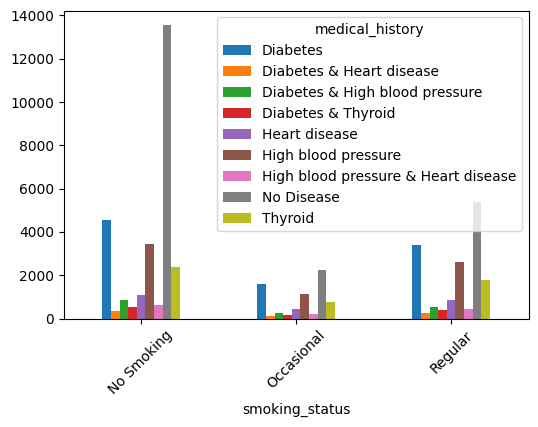

In [100]:
ct = pd.crosstab(new_df['smoking_status'],
                 new_df['medical_history'])

ct.plot(kind='bar', figsize=(6,4))
plt.xticks(rotation=45)
plt.show()


In [101]:
new_df.columns


Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount', 'age_group'],
      dtype='object')

In [102]:
pd.crosstab(new_df['income_level'],new_df['insurance_plan'])

insurance_plan,Bronze,Gold,Silver
income_level,,,
10L - 25L,5307,3880,5182
25L - 40L,3683,2840,3750
<10L,12226,931,5486
> 40L,329,3653,2641


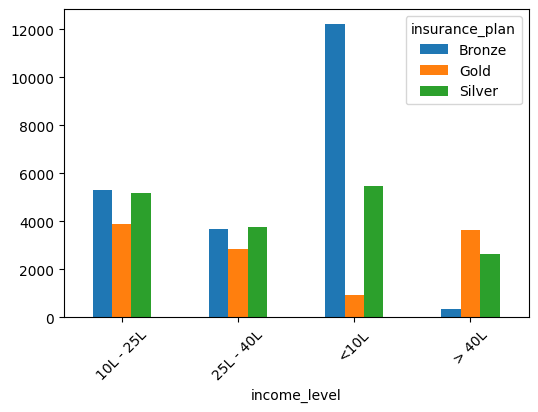

In [103]:
ct = pd.crosstab(new_df['income_level'],new_df['insurance_plan'])

ct.plot(kind='bar', figsize=(6,4))
plt.xticks(rotation=45)
plt.show()


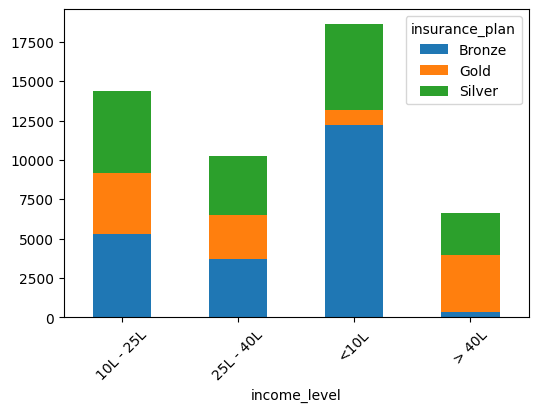

In [104]:
ct = pd.crosstab(new_df['income_level'],new_df['insurance_plan'])

ct.plot(kind='bar', figsize=(6,4),stacked=True)
plt.xticks(rotation=45)
plt.show()


<Axes: xlabel='insurance_plan', ylabel='income_level'>

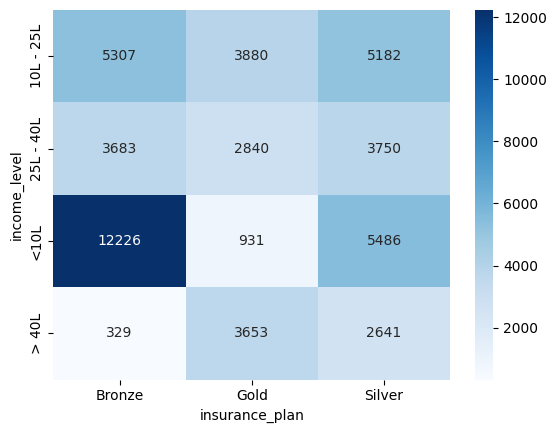

In [105]:
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')

In [106]:
num_col2

['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount']

In [107]:
new_df[['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount']].corr()

,age,number_of_dependants,income_lakhs,annual_premium_amount
age,1.000000,0.415742,0.025060,0.767569
number_of_dependants,0.415742,1.000000,0.006074,0.414691
income_lakhs,0.025060,0.006074,1.000000,0.243058
annual_premium_amount,0.767569,0.414691,0.243058,1.000000


In [108]:
new_df.head(4)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,age_group
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,20-40
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,20-40
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,40-60
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,20-40


In [109]:
new_df.medical_history.unique()

array(['Diabetes', 'High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Thyroid', 'Heart disease',
       'High blood pressure & Heart disease', 'Diabetes & Thyroid',
       'Diabetes & Heart disease'], dtype=object)

In [110]:
risk_score={
    'no disease':0,
    'thyroid':5,
    'diabetes':6,    
    'high blood pressure':6,
    'heart disease':8,
    'none':0
}


In [111]:
new_df[['disease_1','disease_2']]=new_df['medical_history'].str.split(" & ",expand=True).apply(lambda x: x.str.lower())
new_df.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,age_group,disease_1,disease_2
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,20-40,diabetes,None
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,20-40,diabetes,None


In [112]:
new_df['disease_1'].unique()
new_df['disease_2'].unique()


array([None, 'high blood pressure', 'heart disease', 'thyroid'],
      dtype=object)

In [113]:
new_df['disease_1'] = new_df['disease_1'].str.strip().str.lower()
new_df['disease_2'] = new_df['disease_2'].str.strip().str.lower()


In [114]:
new_df['total_risk_score'] = (
    new_df['disease_1'].map(risk_score).fillna(0) +
    new_df['disease_2'].map(risk_score).fillna(0)
)


In [115]:
risk_score={
    'no disease':0,
    'thyroid':5,
    'diabetes':6,    
    'high blood pressure':6,
    'heart disease':8,
    'none':0
}

new_df['disease_1']=new_df['disease_1'].fillna('none')
new_df['disease_2']=new_df['disease_2'].fillna('none')
new_df['total_risk_score']=0
for disease in ['disease_1','disease_2']:
    new_df['total_risk_score'] +=new_df[disease].map(risk_score)

new_df

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,age_group,disease_1,disease_2,total_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,20-40,diabetes,none,6
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,20-40,diabetes,none,6
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,40-60,high blood pressure,none,6
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,20-40,no disease,none,0
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,0-20,high blood pressure,none,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,No Disease,Bronze,9111,20-40,no disease,none,0
49996,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Thyroid,Gold,27076,40-60,thyroid,none,5
49997,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,No Disease,Bronze,8564,20-40,no disease,none,0
49998,18,Male,Northwest,Unmarried,2,Normal,No Smoking,Salaried,10L - 25L,20,No Disease,Bronze,9490,0-20,no disease,none,0


In [116]:
max_score=new_df['total_risk_score'].max()
min_score=new_df['total_risk_score'].min()
new_df['normalized_risk_score']=(new_df['total_risk_score']-min_score)/(max_score-min_score)

new_df['normalized_risk_score'].unique()

array([0.42857143, 0.        , 0.85714286, 0.35714286, 0.57142857,
       1.        , 0.78571429])

In [117]:
new_df['total_risk_score'].unique()
new_df['normalized_risk_score'].nunique()
new_df.head(70)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,age_group,disease_1,disease_2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,20-40,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,20-40,diabetes,none,6,0.428571
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,40-60,high blood pressure,none,6,0.428571
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,20-40,no disease,none,0,0.000000
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,0-20,high blood pressure,none,6,0.428571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,34,Female,Southeast,Married,3,Normal,No Smoking,Self-Employed,25L - 40L,35,Thyroid,Gold,22029,20-40,thyroid,none,5,0.357143
66,54,Female,Southeast,Married,4,Overweight,No Smoking,Salaried,25L - 40L,37,Thyroid,Gold,28293,40-60,thyroid,none,5,0.357143
67,22,Male,Northeast,Unmarried,0,Normal,No Smoking,Salaried,<10L,5,No Disease,Bronze,6950,20-40,no disease,none,0,0.000000
68,26,Female,Southwest,Married,2,Overweight,No Smoking,Self-Employed,25L - 40L,28,High blood pressure & Heart disease,Silver,21260,20-40,high blood pressure,heart disease,14,1.000000


In [133]:
df.insurance_plan.unique()

array(['Bronze', 'Silver', 'Gold'], dtype=object)

# Encoding Columns

### Insurance_Plan
- Insurance plan have 3 unique value array(['Bronze', 'Silver', 'Gold'], dtype=object).
- These will consider under ordinal, so assigning value Bronze -1, Silver -2, Gold -3.


In [124]:
test_df['insurance_plan']=new_df['insurance_plan'].map({'Bronze':1, 'Silver':2, 'Gold':3})
test_df.insurance_plan.unique()

array([nan])

In [129]:
print(id(new_df))
print(id(test_df))


1799236508912
1799267295648


In [126]:
print(new_df['insurance_plan'].dtype)
print(new_df['insurance_plan'].unique())


int64
[1 2 3]


In [130]:
mapping = {'Bronze':1, 'Silver':2, 'Gold':3}

if new_df['insurance_plan'].dtype == 'object':
    new_df['insurance_plan'] = new_df['insurance_plan'].map(mapping)
new_df['insurance_plan'].unique()

array([1, 2, 3])

### Income_Level
- Income Level have 4 unique value array(['<10L', '10L - 25L', '> 40L', '25L - 40L'], dtype=object).
- These will consider under ordinal data, so assigning values
  - '<10L':1
  - '10L - 25L':2
  - '25L - 40L':3
  - '> 40L':4


In [135]:
new_df.income_level.unique()

array(['<10L', '10L - 25L', '> 40L', '25L - 40L'], dtype=object)

In [136]:
income_level={
    '<10L':1,
    '10L - 25L':2,
     '25L - 40L':3,
    '> 40L':4,
}
if new_df['income_level'].dtype == 'object':
    new_df['income_level'] = new_df['income_level'].map(income_level)
new_df['income_level'].unique()

array([1, 2, 4, 3])

In [138]:
new_df.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,age_group,disease_1,disease_2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,1,6,Diabetes,1,9053,20-40,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,1,6,Diabetes,1,16339,20-40,diabetes,none,6,0.428571


### One Hot Encoding

- Applying one hog encoding for the mentioned columns because these are nominal category columns.
- gender,region,marital_status,bmi_category, smoking_status, employment_status

In [141]:
nominal_col=['gender', 'region', 'marital_status','bmi_category', 'smoking_status', 'employment_status']

In [143]:
df3=pd.get_dummies(new_df,columns=nominal_col,drop_first=True,dtype=int)
df3.head(5)

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,age_group,disease_1,disease_2,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,Diabetes,1,9053,20-40,diabetes,none,...,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,Diabetes,1,16339,20-40,diabetes,none,...,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,High blood pressure,2,18164,40-60,high blood pressure,none,...,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,No Disease,3,20303,20-40,no disease,none,...,1,0,0,0,0,0,0,0,1,0
4,18,0,4,99,High blood pressure,2,13365,0-20,high blood pressure,none,...,0,0,1,0,1,0,0,1,0,1


In [144]:
df3.columns

Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
       'medical_history', 'insurance_plan', 'annual_premium_amount',
       'age_group', 'disease_1', 'disease_2', 'total_risk_score',
       'normalized_risk_score', 'gender_Male', 'region_Northwest',
       'region_Southeast', 'region_Southwest', 'marital_status_Unmarried',
       'bmi_category_Obesity', 'bmi_category_Overweight',
       'bmi_category_Underweight', 'smoking_status_Occasional',
       'smoking_status_Regular', 'employment_status_Salaried',
       'employment_status_Self-Employed'],
      dtype='object')

- Dropping the columns whichi s not useful or already encoded 

In [152]:
df4=df3.drop(['medical_history','age_group', 'disease_1', 'disease_2','total_risk_score'],axis=1)
df4.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,3,20303,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,18,0,4,99,2,13365,0.428571,1,0,0,0,1,0,1,0,0,1,0,1


# Drawing Correction Matrix To Analysis

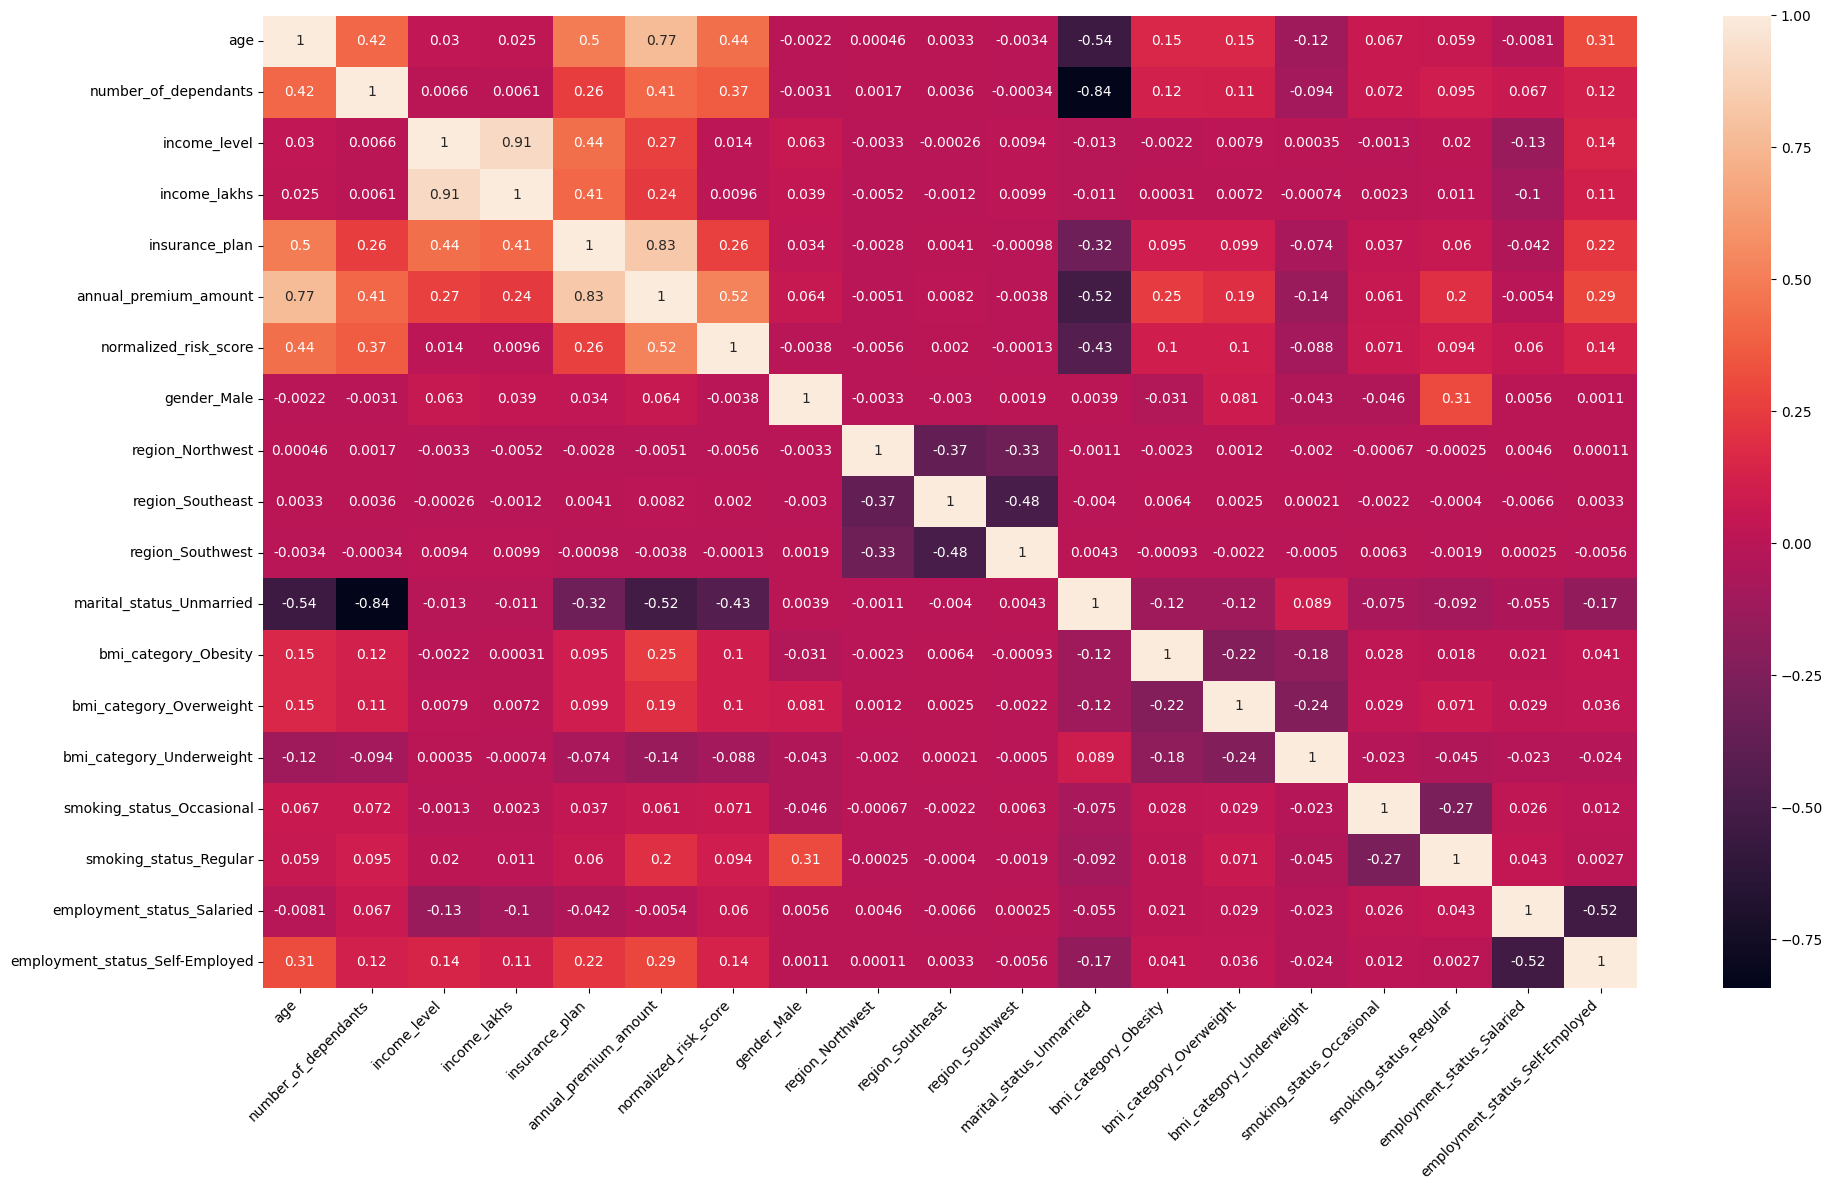

In [153]:
cm=df4.corr()
plt.figure(figsize=(20,12))
sns.heatmap(cm,annot=True)
plt.xticks(rotation=45,ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Heatmap Analysis With Respect to Target Columns

- Insurance plan score 0.83 - Strong relation - with annual premium amount.
- Age :0.77 - strong relation — older people pay more because they have heigher health risk
- Number of dependents:0.41 - moderate risk - much repsonsiablity - high pay burdern is risky
- (Disease factor) Normalized risk factor :0.53 : Strong relation - larger annual premium amount can be risky.
- Marital status: - 0.52 : Strong Negative - Marital people pay less in insurance.
- Income level Vs Income in lakhs: 0.91 - These two columns are almost perfectly correlated!, They're telling the model the same thing twice.
    
    - This is called MULTICOLLINEARITY
    - So, need to DROP one of them (keep income_lakhs, drop income_level)
- Marital status Vs numer of dependents : -0.84 Strong colliear relation.
    
    - Strong negative — unmarried people have fewer dependants
    - Makes real-world sense!
    - But again — two columns saying similar things
    - Be careful about keeping both

- Region Southeast Vs Region South West: -0.48

  - Moderate negative between regions
  - This is normal for one-hot encoded columns
  - (if you're in Southeast, you're NOT in Southwest)
  - Not a problem, expected behavior

- employment_status_Self-Employed vs employment_status_Salaried: -0.52
    
    - Same reason — one-hot encoded columns
    - If Salaried=1, Self-Employed=0 → naturally negative
    - Not a problem

In [157]:
correlation_with_target = df4.corr()['annual_premium_amount'].sort_values(ascending=False)
print(correlation_with_target)

annual_premium_amount              1.000000
insurance_plan                     0.834148
age                                0.767569
normalized_risk_score              0.519458
number_of_dependants               0.414691
employment_status_Self-Employed    0.289438
income_level                       0.271811
bmi_category_Obesity               0.249847
income_lakhs                       0.243058
smoking_status_Regular             0.198829
bmi_category_Overweight            0.187103
gender_Male                        0.064470
smoking_status_Occasional          0.060610
region_Southeast                   0.008235
region_Southwest                  -0.003828
region_Northwest                  -0.005078
employment_status_Salaried        -0.005442
bmi_category_Underweight          -0.135289
marital_status_Unmarried          -0.516350
Name: annual_premium_amount, dtype: float64


### Strong Positive (Above 0.5) — Must Keep Features

<table border="1" cellpadding="8" cellspacing="0">
    <thead>
        <tr>
            <th>Feature</th>
            <th>Correlation</th>
            <th>Real World Meaning</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>insurance_plan</td>
            <td>0.83</td>
            <td>Higher plan tier = higher premium. Most obvious driver.</td>
        </tr>
        <tr>
            <td>age</td>
            <td>0.77</td>
            <td>Older people = more health risks = pay more.</td>
        </tr>
        <tr>
            <td>normalized_risk_score</td>
            <td>0.52</td>
            <td>Combines all risk factors — diseases, smoking, BMI.</td>
        </tr>
    </tbody>
</table>

<table border="1" cellpadding="8" cellspacing="0">
    <thead>
        <tr>
            <th>Feature</th>
            <th>Correlation</th>
            <th>Real World Meaning</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>number_of_dependants</td>
            <td>0.41</td>
            <td>More dependants = more coverage needed = higher premium.</td>
        </tr>
        <tr>
            <td>employment_status_Self-Employed</td>
            <td>0.29</td>
            <td>Self-employed = unstable income = higher risk category.</td>
        </tr>
        <tr>
            <td style="color:red">income_level</td>
            <td>0.27</td>
            <td>⚠️ Multicollinear with income_lakhs — drop this.</td>
        </tr>
        <tr>
            <td>bmi_category_Obesity</td>
            <td>0.25</td>
            <td>Obese people have more health risks = higher premium.</td>
        </tr>
        <tr>
            <td>income_lakhs</td>
            <td>0.24</td>
            <td>Keep this, drop income_level.</td>
        </tr>
        <tr>
            <td>smoking_status_Regular</td>
            <td>0.20</td>
            <td>Regular smokers pay more — health risk.</td>
        </tr>
    </tbody>
</table>


<h3>Weak Positive (0 to 0.2) — Low Value Features</h3>

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse; width: 85%;">
    <thead style="background-color: #f2f2f2;">
        <tr>
            <th>Feature</th>
            <th>Correlation</th>
            <th>Decision</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>bmi_category_Overweight</td>
            <td>0.19</td>
            <td>Borderline — keep for now.</td>
        </tr>
        <tr>
            <td style="color:red">gender_Male</td>
            <td style="color:red">0.06</td>
            <td style="color:red">Very weak — gender barely affects premium.</td>
        </tr>
        <tr>
            <td style="color:red">smoking_status_Occasional</td>
            <td style="color:red">0.06</td>
            <td style="color:red">Very weak — occasional smoking has little impact.</td>
        </tr>
        <tr>
            <td style="color:red">region_Southeast</td>
            <td style="color:red">0.008</td>
            <td style="color:red">Almost zero — region doesn't matter much.</td>
        </tr>
        <tr>
            <td style="color:red">region_Southwest</td>
            <td style="color:red">-0.003</td>
            <td style="color:red">Almost zero.</td>
        </tr>
        <tr>
            <td style="color:red">region_Northwest</td>
            <td style="color:red">-0.005</td>
            <td style="color:red">Almost zero.</td>
        </tr>
        <tr>
            <td style="color:red" >employment_status_Salaried</td>
            <td style="color:red">-0.005</td>
            <td style="color:red">Almost zero.</td>
        </tr>
    </tbody>
</table>

<h3>Strong Negative — Important!</h3>

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse; width: 85%;">
    <thead style="background-color: #f2f2f2;">
        <tr>
            <th>Feature</th>
            <th>Correlation</th>
            <th>Real World Meaning</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>marital_status_Unmarried</td>
            <td>-0.52</td>
            <td>Unmarried = fewer dependants = lower premium.</td>
        </tr>
        <tr>
            <td>bmi_category_Underweight</td>
            <td>-0.14</td>
            <td>Underweight people pay less? Needs investigation.</td>
        </tr>
    </tbody>
</table>



In [158]:
df5=df4.drop(['income_level'],axis=1)
df5.head()

,age,number_of_dependants,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,6,1,9053,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,6,1,16339,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,20,2,18164,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,30,3,77,3,20303,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,18,0,99,2,13365,0.428571,1,0,0,0,1,0,1,0,0,1,0,1


In [159]:
df5.head(5)

,age,number_of_dependants,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,6,1,9053,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,6,1,16339,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,20,2,18164,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,30,3,77,3,20303,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,18,0,99,2,13365,0.428571,1,0,0,0,1,0,1,0,0,1,0,1


In [163]:
df5.describe()

,age,number_of_dependants,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.00000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000
mean,34.401579,1.717640,22.889897,1.794802,15765.739641,0.291831,0.549631,0.20093,0.350385,0.303038,0.513545,0.143183,0.231245,0.155326,0.138274,0.313857,0.419412,0.272041
std,13.681604,1.492032,22.170699,0.784919,8418.674061,0.287420,0.497536,0.40070,0.477095,0.459576,0.499822,0.350263,0.421633,0.362219,0.345191,0.464064,0.493468,0.445015
min,18.000000,0.000000,1.000000,1.000000,3501.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,0.000000,7.000000,1.000000,8608.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,31.000000,2.000000,17.000000,2.000000,13928.000000,0.357143,1.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,45.000000,3.000000,31.000000,2.000000,22270.500000,0.428571,1.000000,0.00000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,72.000000,5.000000,100.000000,3.000000,43471.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [162]:
x=df5.drop('annual_premium_amount',axis='columns')
y=df5['annual_premium_amount']


0         9053
1        16339
2        18164
3        20303
4        13365
         ...  
49995     9111
49996    27076
49997     8564
49998     9490
49999    19730
Name: annual_premium_amount, Length: 49908, dtype: int64

## Feature Scaling

- Doing the feature scaling because few columns have very high value and value low, so without scaling, model can show the biased result.
- Feature Scaling Columns: age,number_of_dependants,income_lakhs,insurance_plan

In [167]:
# import sklearn liberary of MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

cols_to_scale=['age','number_of_dependants','income_lakhs','insurance_plan']
scaler=MinMaxScaler()
x[cols_to_scale]=scaler.fit_transform(x[cols_to_scale])
x.head()

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.148148,0.0,0.050505,0.0,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,0.203704,0.4,0.050505,0.0,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,0.574074,0.4,0.191919,0.5,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,0.222222,0.6,0.767677,1.0,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,0.000000,0.0,0.989899,0.5,0.428571,1,0,0,0,1,0,1,0,0,1,0,1


In [168]:
x.describe()

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.00000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000
mean,0.303733,0.343528,0.221110,0.397401,0.291831,0.549631,0.20093,0.350385,0.303038,0.513545,0.143183,0.231245,0.155326,0.138274,0.313857,0.419412,0.272041
std,0.253363,0.298406,0.223946,0.392459,0.287420,0.497536,0.40070,0.477095,0.459576,0.499822,0.350263,0.421633,0.362219,0.345191,0.464064,0.493468,0.445015
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.074074,0.000000,0.060606,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.240741,0.400000,0.161616,0.500000,0.357143,1.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.500000,0.600000,0.303030,0.500000,0.428571,1.000000,0.00000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Variance Inflation Factor (VIF) Score : Check Multicolinearity Relation

In [170]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [174]:
def calculate_vif(data):
    vif_df=pd.DataFrame()
    vif_df['Columns']=data.columns
    vif_df['VIF']=[variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [175]:
calculate_vif(x)

,Columns,VIF
0,age,4.545825
1,number_of_dependants,4.526598
2,income_lakhs,2.480563
3,insurance_plan,3.445682
4,normalized_risk_score,2.687326
5,gender_Male,2.409980
6,region_Northwest,2.100789
7,region_Southeast,2.919775
8,region_Southwest,2.668314
9,marital_status_Unmarried,3.393718


## Model Training

In [192]:
# use for split the training and test data
from sklearn.model_selection import train_test_split

# use for model building
from sklearn.linear_model import LinearRegression



In [185]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
print("X Training Data Size",x_train.shape)
print("X Test Data Size",x_test.shape)
print("Y Training Data Size",y_train.shape)
print("Y Test Data Size",y_test.shape)

X Training Data Size (34935, 17)
X Test Data Size (14973, 17)
Y Training Data Size (34935,)
Y Test Data Size (14973,)


In [193]:
lr_model=LinearRegression()


In [194]:
lr_model.fit(x_test,y_test)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Model Performance Check

- Train Score< Test Score - So, it is not overfit

In [198]:

train_score=lr_model.score(x_train,y_train)
test_score=lr_model.score(x_test,y_test)
print("Train score:",train_score)
print("Test score:",test_score)

Train score: 0.9280035303296611
Test score: 0.9284677404116805


In [207]:
feature_importances=lr_model.coef_
intercept=lr_model.intercept_

In [211]:
print(feature_importances)
x_test.head(1)

[ 1.12517490e+04 -6.47687449e+02 -5.41966662e+02  1.25361182e+04
  4.77638366e+03  2.04435538e+02 -6.02787536e+01  5.74184635e+01
 -4.17523683e+00 -9.56073571e+02  3.35134949e+03  1.60363557e+03
  3.02436145e+02  7.15410814e+02  2.17250555e+03  1.45136845e+02
  3.93170883e+02]


,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
24098,0.351852,0.6,0.010101,0.0,0.428571,0,1,0,0,0,0,0,0,0,0,1,0


In [214]:
coef_df=pd.DataFrame(feature_importances,index=x_test.columns,columns=["Coefficient"])
coef_df

,Coefficient
age,11251.749016
number_of_dependants,-647.687449
income_lakhs,-541.966662
insurance_plan,12536.118236
normalized_risk_score,4776.383656
gender_Male,204.435538
region_Northwest,-60.278754
region_Southeast,57.418464
region_Southwest,-4.175237
marital_status_Unmarried,-956.073571


In [218]:
coef_sort=coef_df.sort_values(by='Coefficient',ascending=True)
coef_sort

,Coefficient
marital_status_Unmarried,-956.073571
number_of_dependants,-647.687449
income_lakhs,-541.966662
region_Northwest,-60.278754
region_Southwest,-4.175237
region_Southeast,57.418464
employment_status_Salaried,145.136845
gender_Male,204.435538
bmi_category_Underweight,302.436145
employment_status_Self-Employed,393.170883


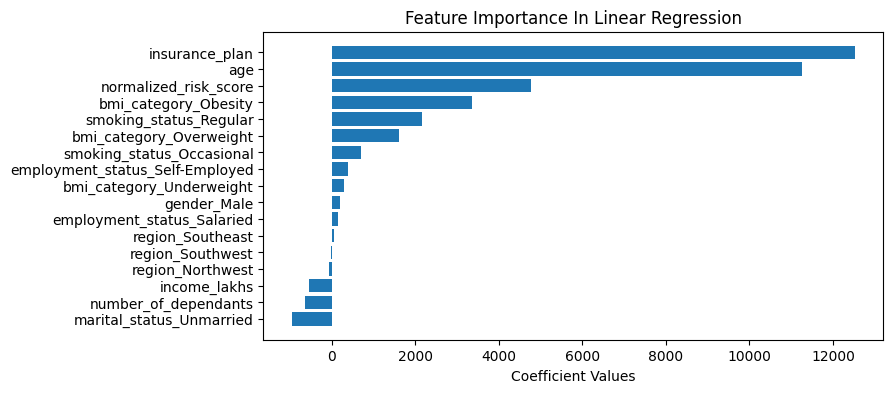

In [220]:
plt.figure(figsize=(8,4))
plt.barh(coef_sort.index,coef_sort.Coefficient)
plt.xlabel("Coefficient Values")
plt.title("Feature Importance In Linear Regression")
plt.show()

# Check The Performance Score With Other Linear Regression Model

In [261]:
from sklearn.linear_model import Ridge
rg_model=Ridge()

In [262]:
rg_model.fit(x_test,y_test)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [263]:


rg_train_score=rg_model.score(x_train,y_train)
rg_test_score=rg_model.score(x_test,y_test)
print("Train score:",rg_train_score)
print("Test score:",rg_test_score)

Train score: 0.9280036378697165
Test score: 0.9284675314552588


### XGBOOST Model

In [264]:
from xgboost import XGBRegressor


In [265]:
xgb_model = XGBRegressor()


In [267]:
xgb_model.fit(x_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [268]:
xgb_train_score=xgb_model.score(x_train,y_train)
xgb_test_score=xgb_model.score(x_test,y_test)
print("Train score:",xgb_train_score)
print("Test score:",xgb_test_score)

Train score: 0.9861041903495789
Test score: 0.9807721972465515


## Evaluation Matrics: How good is my model is? 

| Metric      | When To Use                                |
| ----------- | ------------------------------------------ |
| MSE         | When large errors must be punished heavily |
| RMSE        | When you want interpretable error          |
| R²          | To measure model goodness overall          |
| Adjusted R² | When multiple features exist               |


### Our Target: 97%

In [271]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# calculating predicted value by the model
y_pred = lr_model.predict(x_test)

# calculating the mean square error
mse = mean_squared_error(y_test, y_pred)

# calculating mean squared error
rmse = np.sqrt(mse)

# calculating r^2 (Coefficient of Determination.)
r2 = r2_score(y_test, y_pred)


# Calculating adjusted r^2
n = x_test.shape[0]
p = x_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)
print("Adjusted R2:", adj_r2)


MSE: 5050204.537200549
RMSE: 2247.2660138934484
R2: 0.9284677404116805
Adjusted R2: 0.9283864265759733


In [272]:
# calculating predicted value by the model
y_pred_xgb = xgb_model.predict(x_test)

# calculating the mean square error
mse = mean_squared_error(y_test, y_pred_xgb)

# calculating mean squared error
rmse = np.sqrt(mse)

# calculating r^2 (Coefficient of Determination.)
r2 = r2_score(y_test, y_pred_xgb)


# Calculating adjusted r^2
n = x_test.shape[0]
p = x_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)
print("Adjusted R2:", adj_r2)


MSE: 1357488.75
RMSE: 1165.1131919260033
R2: 0.9807721972465515
Adjusted R2: 0.9807503401655212


## SOW Target: 97%

- **SOW Target:**  97% accuracy
- **Our Model Performance:**  98.07% R²

<h3>Full Model Report Card</h3>

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse; width: 85%;">
    <thead style="background-color: #f2f2f2;">
        <tr>
            <th>Metric</th>
            <th>Value</th>
            <th>Meaning</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>R²</td>
            <td>98.07%</td>
            <td>Model explains 98% of premium variation.</td>
        </tr>
        <tr>
            <td>Adjusted R²</td>
            <td>98.07%</td>
            <td>All features genuinely useful ✅</td>
        </tr>
        <tr>
            <td>RMSE</td>
            <td>₹1,165</td>
            <td>Average prediction error is only ₹1,165.</td>
        </tr>
        <tr>
            <td>MSE</td>
            <td>13,57,488</td>
            <td>Squared error (just for reference).</td>
        </tr>
    </tbody>
</table>


For testing better hyper parameter CV
ramdomize search cv, 
grid search cv

In [279]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
import numpy as np

# Step 1 — Define parameter grid
# Keep it small — each combination trains cv=3 times!
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7]
}
# Total = 3×3×3 = 27 combinations × 3 folds = 81 models!

# Step 2 — Create base model
xgb = XGBRegressor(random_state=42)

# Step 3 — Create GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb,          # your model
    param_grid=param_grid,  # combinations to try
    cv=3,                   # 3-fold cross validation
    scoring='r2',           # metric to optimize
    verbose=2,              # show progress
    n_jobs=-1               # use all CPU cores (faster)
)

# Step 4 — Fit (this will take time!)
grid_search.fit(x_train, y_train)

# Step 5 — Results
print("Best Parameters:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

# Step 6 — Evaluate on test set
best_grid_model = grid_search.best_estimator_
grid_pred = best_grid_model.predict(x_test)

from sklearn.metrics import r2_score, mean_squared_error
print(f"Test R²: {r2_score(y_test, grid_pred):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, grid_pred)):.2f}")


Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best CV R²: 0.9819395939509074
Test R²: 0.9819
Test RMSE: 1131.28


<h3>Improvement Comparison</h3>

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse; width: 85%;">
    <thead style="background-color: #f2f2f2;">
        <tr>
            <th>Model</th>
            <th>R²</th>
            <th>RMSE</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>XGBoost (default)</td>
            <td>98.07%</td>
            <td>₹1,165</td>
        </tr>
        <tr>
            <td>XGBoost (GridSearch)</td>
            <td>98.19%</td>
            <td>₹1,131</td>
        </tr>
        <tr>
            <td><strong>Improvement</strong></td>
            <td><strong>+0.12%</strong></td>
            <td><strong>₹34 less error</strong></td>
        </tr>
    </tbody>
</table>


<h3>Why This Matters</h3>

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse; width: 85%;">
    <thead style="background-color: #f2f2f2;">
        <tr>
            <th>Situation</th>
            <th>Meaning</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>CV R² &gt;&gt; Test R²</td>
            <td>Overfitting — model memorized training data.</td>
        </tr>
        <tr>
            <td>CV R² ≈ Test R²</td>
            <td>Perfect — model generalizes well ✅</td>
        </tr>
        <tr>
            <td>CV R² &lt;&lt; Test R²</td>
            <td>Lucky test split — not reliable.</td>
        </tr>
    </tbody>
</table>


In [280]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
import numpy as np

# Step 1 — Define LARGER parameter grid
# Can afford bigger grid since we're sampling randomly
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7]
}
# Total possible = 5×6×6×5×5×4 = 18,000 combinations
# We'll only try 50!

# Step 2 — Create base model
xgb = XGBRegressor(random_state=42)

# Step 3 — Create RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,          # only try 50 random combinations
    cv=3,               # 3-fold cross validation
    scoring='r2',       # metric to optimize
    verbose=2,          # show progress
    n_jobs=-1,          # use all CPU cores
    random_state=42     # reproducible results
)

# Step 4 — Fit
random_search.fit(x_train, y_train)

# Step 5 — Results
print("Best Parameters:", random_search.best_params_)
print("Best CV R²:", random_search.best_score_)

# Step 6 — Evaluate on test set
best_random_model = random_search.best_estimator_
random_pred = best_random_model.predict(x_test)

print(f"Test R²: {r2_score(y_test, random_pred):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, random_pred)):.2f}")


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 7, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV R²: 0.9819228649139404
Test R²: 0.9819
Test RMSE: 1130.25


<h3>📊 Full Comparison — All 3 Models</h3>

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse; width: 95%;">
    <thead style="background-color: #f2f2f2;">
        <tr>
            <th>Model</th>
            <th>R²</th>
            <th>RMSE</th>
            <th>Parameters</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>XGBoost (Default)</td>
            <td>98.07%</td>
            <td>₹1,165</td>
            <td>Default settings</td>
        </tr>
        <tr>
            <td>GridSearchCV</td>
            <td>98.19%</td>
            <td>₹1,131</td>
            <td>learning_rate=0.1, max_depth=5, n_estimators=100</td>
        </tr>
        <tr>
            <td>RandomizedSearchCV</td>
            <td>98.19%</td>
            <td>₹1,130</td>
            <td>learning_rate=0.05, max_depth=4, n_estimators=300</td>
        </tr>
    </tbody>
</table>


<h3>Hyperparameter Comparison — GridSearch vs RandomizedSearch</h3>

<table border="1" cellpadding="8" cellspacing="0" style="border-collapse: collapse; width: 85%;">
    <thead style="background-color: #f2f2f2;">
        <tr>
            <th>Parameter</th>
            <th>GridSearch</th>
            <th>RandomizedSearch</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>learning_rate</td>
            <td>0.1</td>
            <td>0.05</td>
        </tr>
        <tr>
            <td>max_depth</td>
            <td>5</td>
            <td>4</td>
        </tr>
        <tr>
            <td>n_estimators</td>
            <td>100</td>
            <td>300</td>
        </tr>
        <tr>
            <td>subsample</td>
            <td>-</td>
            <td>0.8</td>
        </tr>
        <tr>
            <td>min_child_weight</td>
            <td>-</td>
            <td>7</td>
        </tr>
        <tr>
            <td>colsample_bytree</td>
            <td>-</td>
            <td>1.0</td>
        </tr>
    </tbody>
</table>

#### Paramter Analysis

- Slow learning rate (0.05) + More trees (300) = Same result as
- Fast learning rate (0.1)  + Fewer trees (100)
- This is called the Learning Rate - Trees Tradeoff!
- Lower learning rate → needs MORE trees to compensate
- Higher learning rate → needs FEWER trees

#### RMSE Difference:

- GridSearch   RMSE = ₹1,131.28
- RandomSearch RMSE = ₹1,130.25
- Difference = ₹1.03 → Almost nothing!

### Which Model we should choose?

- RandomizedSearchCV winner — but barely!
- Reasons to pick RandomizedSearchCV:
- ✅ Slightly lower RMSE (₹1,130 vs ₹1,131)
- ✅ More parameters tuned (6 vs 3)
- ✅ Explored much larger search space
- ✅ Found additional useful params (subsample, min_child_weight)

## New Model Feature Importances

In [288]:
bfi=best_random_model.feature_importances_
bfi

array([3.6254802e-01, 3.0382010e-04, 2.8706799e-04, 5.1955754e-01,
       2.6153374e-02, 3.3152680e-04, 3.4754165e-04, 2.6775044e-04,
       2.9541308e-04, 3.3169243e-04, 3.6328655e-02, 1.6589219e-02,
       1.0025724e-03, 3.9040765e-03, 3.1227030e-02, 2.6742811e-04,
       2.5726677e-04], dtype=float32)

#### Creating New DataFrame With Labeling

In [295]:
bfi_df=pd.DataFrame(bfi,index=x_test.columns,columns=["Feature_Importances"])
bfi_df

,Feature_Importances
age,0.362548
number_of_dependants,0.000304
income_lakhs,0.000287
insurance_plan,0.519558
normalized_risk_score,0.026153
gender_Male,0.000332
region_Northwest,0.000348
region_Southeast,0.000268
region_Southwest,0.000295
marital_status_Unmarried,0.000332


#### Arranging in ascending order

In [296]:

sorted_bfi_df=bfi_df.sort_values(by='Feature_Importances',ascending=True)
sorted_bfi_df

,Feature_Importances
employment_status_Self-Employed,0.000257
employment_status_Salaried,0.000267
region_Southeast,0.000268
income_lakhs,0.000287
region_Southwest,0.000295
number_of_dependants,0.000304
gender_Male,0.000332
marital_status_Unmarried,0.000332
region_Northwest,0.000348
bmi_category_Underweight,0.001003


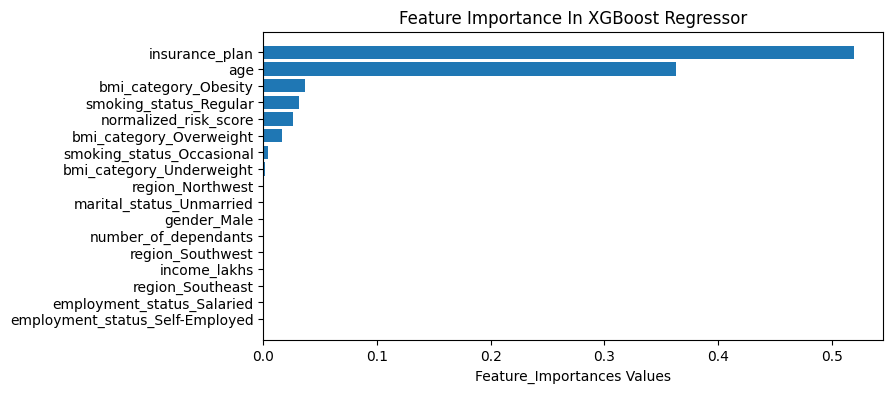

In [297]:
plt.figure(figsize=(8,4))
plt.barh(sorted_bfi_df.index,sorted_bfi_df.Feature_Importances)
plt.xlabel("Feature_Importances Values")
plt.title("Feature Importance In XGBoost Regressor")
plt.show()

### Error Analysis

In [303]:
# predicted value for x_test data
y_pred=best_random_model.predict(x_test)

# residuals calculation
residual=y_pred-y_test

# percent deviation
residual_pct=residual*100/y_test

# Dataframe of the y_test and y_prediction
result_df=pd.DataFrame({
    "y_pred":y_pred,
    "y_test":y_test,
    "residuals":residual,
    "diff_pct":residual_pct
})

result_df.head()

,y_pred,y_test,residuals,diff_pct
24098,9172.521484,9246,-73.478516,-0.794706
201,13338.745117,11664,1674.745117,14.358240
25471,7370.042969,10472,-3101.957031,-29.621438
32500,25992.759766,26267,-274.240234,-1.044049
30832,9200.491211,9106,94.491211,1.037681


<Axes: xlabel='diff_pct', ylabel='Count'>

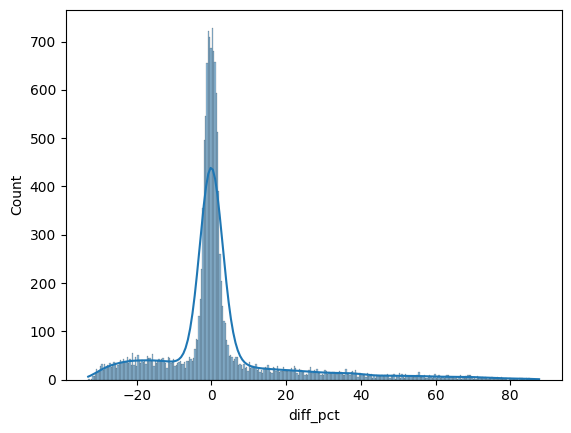

In [304]:
sns.histplot(result_df['diff_pct'],kde=True)

In [306]:
extreme_threshold=10

extreme_result_df=result_df[np.abs(result_df.diff_pct)>extreme_threshold]

extreme_result_df.shape

(4384, 4)

In [308]:
result_df.shape

14973

In [313]:
error_margin_pct=extreme_result_df.shape[0]*100/result_df.shape[0]
pct

29.27936953182395

In [317]:
result_df[np.abs(result_df.diff_pct)>50].sort_values('diff_pct',ascending=False)

,y_pred,y_test,residuals,diff_pct
22007,6808.209473,3627,3181.209473,87.709111
10288,6594.460938,3517,3077.460938,87.502443
23975,6582.828613,3520,3062.828613,87.012177
29904,6534.633789,3503,3031.633789,86.543928
25207,6514.096680,3501,3013.096680,86.063887
...,...,...,...,...
12107,6976.109863,4647,2329.109863,50.120720
49008,8260.245117,5503,2757.245117,50.104400
22445,7334.709961,4887,2447.709961,50.086146
17758,7410.062012,4938,2472.062012,50.062009


In [318]:
x_test.index

Index([24098,   201, 25471, 32500, 30832, 11631, 12814, 33373,  5408, 47939,
       ...
        7746, 25417,  8104, 11125,   679, 12123, 31891,  6713, 16957, 15109],
      dtype='int64', length=14973)

In [319]:
extreme_result_df.index

Index([  201, 25471, 47939, 26239, 16907,  5849, 25369,  8403, 38677, 32319,
       ...
        1521, 23789, 24121,  4068, 41535, 21893, 10319, 37321, 43822,  7746],
      dtype='int64', length=4384)

In [324]:
extreme_error_df=x_test.loc[extreme_result_df.index]
extreme_error_df.head()

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
201,0.129630,0.2,0.636364,1.0,0.0,0,1,0,0,1,0,0,0,0,0,0,0
25471,0.074074,0.0,0.010101,0.0,0.0,1,1,0,0,1,0,1,0,0,1,1,0
47939,0.111111,0.0,0.424242,1.0,0.0,0,1,0,0,1,0,0,1,0,0,1,0
26239,0.037037,0.0,0.292929,0.0,0.0,1,1,0,0,1,0,0,1,0,0,0,0
16907,0.111111,0.0,0.606061,0.5,0.0,1,0,0,0,1,0,0,1,0,1,0,0


<Axes: xlabel='income_lakhs', ylabel='Count'>

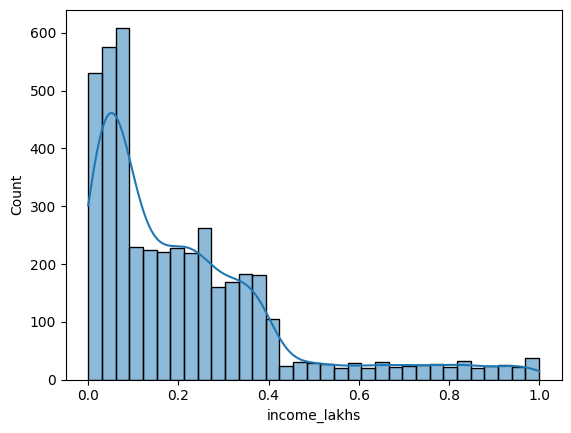

In [325]:
sns.histplot(extreme_error_df.income_lakhs,kde=True)

In [329]:
extreme_col=extreme_error_df.columns


17

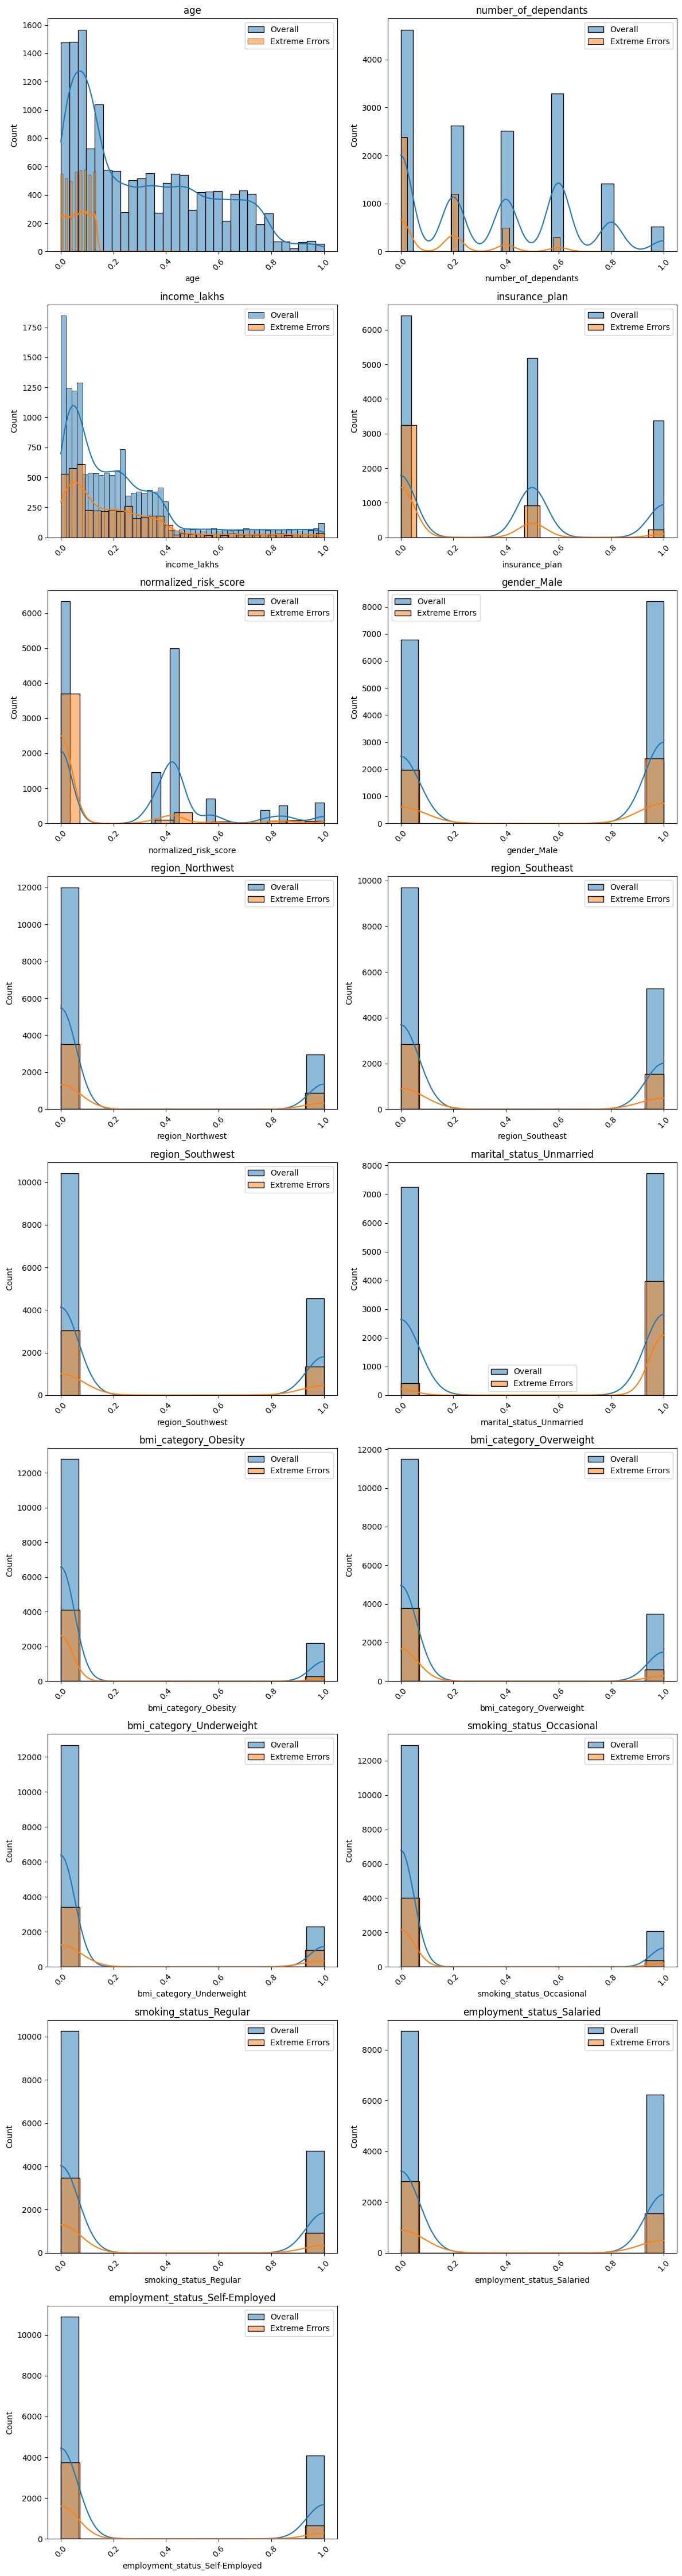

In [340]:
n_cols = 2   # fixed number of columns per row (standard)
n_rows = math.ceil(len(extreme_col) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()

# fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, col in zip(axes, extreme_col):
    sns.histplot(x_test[col],label="Overall",kde=True,ax=ax)
    sns.histplot(extreme_error_df[col],label="Extreme Errors",kde=True,ax=ax) 
    ax.legend()
    ax.set_title(f'{col}')    
    ax.tick_params(axis='x', rotation=45)

# Remove extra plots
for j in range(len(extreme_col), len(axes)):
    fig.delaxes(axes[j])
    
plt.legend()
plt.tight_layout()
plt.show()


## Reverse Transform

- From the visual representation, we can see there are the majority difference in the pattern in age graph.
- 

In [343]:
cols_to_scale

['age', 'number_of_dependants', 'income_lakhs', 'insurance_plan']

<Axes: xlabel='age', ylabel='Count'>

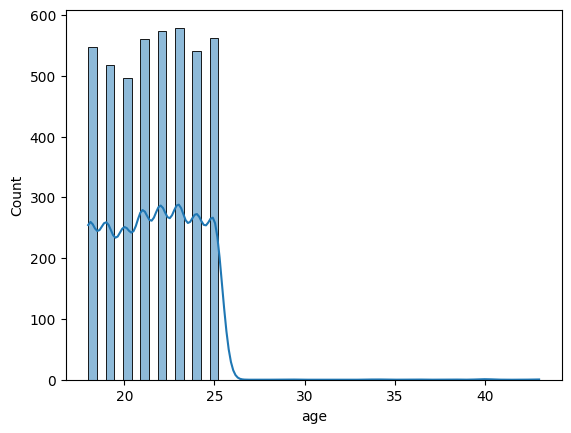

In [346]:
df_reversed=pd.DataFrame()
df_reversed[cols_to_scale]=scaler.inverse_transform(extreme_error_df[cols_to_scale])
sns.histplot(df_reversed['age'],kde=True)

In [357]:
df_reversed['age'].quantile(0.998)

np.float64(25.0)